## Imports

In [9]:
#pip install numpy pandas matplotlib seaborn plotly scikit-learn scipy missingno tensorflow torch xgboost


In [13]:
# ===============================
# 📦 Data Science Project Imports
# ===============================

# Core
import numpy as np
import pandas as pd


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Preprocessing & Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler,
    LabelEncoder, OneHotEncoder
)
from sklearn.impute import SimpleImputer

# Machine Learning Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier
)

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_squared_error, r2_score
)

# Statistics & EDA Helpers
from scipy import stats
#import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# System & Time Utilities
import os
import sys
import datetime as dt

# Deep Learning (optional)
#import tensorflow as tf
#from tensorflow import keras
#import torch


## Load dataset

In [14]:
# If the file is in the same directory as your notebook
combined_data = pd.read_csv('combined_data_labeled_edited.csv')

In [15]:
combined_data.head(5)

,Furnace_Temp,Exist_Temp,Annealing_Temp,Thickness,Width,S,Cu,Ni,Cr,Mo,...,Pb,Ceq,Pcm,Sb,N,O,W,Yield_Strength_MPa,Tensile_Strength_MPa,Elongation_Percent
0,1235,870,585,6.0,1500,0.0028,0.2774,0.1265,0.4813,0.0032,...,0.0001,0.2690,0.1488,0.0001,0.0,0.0,0.0,400,505,35.0
1,1216,868,590,6.0,1500,0.0042,0.2797,0.1389,0.4970,0.0035,...,0.0001,0.2766,0.1523,0.0001,0.0,0.0,0.0,398,500,36.0
2,1205,871,588,8.0,1500,0.0042,0.2797,0.1389,0.4970,0.0035,...,0.0001,0.2766,0.1523,0.0001,0.0,0.0,0.0,396,497,36.5
3,1202,855,583,10.0,1500,0.0042,0.2797,0.1389,0.4970,0.0035,...,0.0001,0.2766,0.1523,0.0001,0.0,0.0,0.0,396,506,35.0
4,1207,855,599,12.0,1500,0.0042,0.2739,0.1352,0.5041,0.0039,...,0.0001,0.2965,0.1733,0.0001,0.0,0.0,0.0,389,513,31.0


In [16]:
# View basic info
combined_data.info()

# Check for missing values
combined_data.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65288 entries, 0 to 65287
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Furnace_Temp          65288 non-null  int64  
 1   Exist_Temp            65288 non-null  int64  
 2   Annealing_Temp        65288 non-null  int64  
 3   Thickness             65288 non-null  float64
 4   Width                 65288 non-null  int64  
 5   S                     65288 non-null  float64
 6   Cu                    65288 non-null  float64
 7   Ni                    65288 non-null  float64
 8   Cr                    65288 non-null  float64
 9   Mo                    65288 non-null  float64
 10  V                     65288 non-null  float64
 11  Nb                    65288 non-null  float64
 12  Al                    65288 non-null  float64
 13  Acid Sol. Al          65288 non-null  float64
 14  Ti                    65288 non-null  float64
 15  B                  

Furnace_Temp            0
Exist_Temp              0
Annealing_Temp          0
Thickness               0
Width                   0
S                       0
Cu                      0
Ni                      0
Cr                      0
Mo                      0
V                       0
Nb                      0
Al                      0
Acid Sol. Al            0
Ti                      0
B                       0
Sn                      0
As                      0
Zr                      0
Ca                      0
Pb                      0
Ceq                     0
Pcm                     0
Sb                      0
N                       0
O                       0
W                       0
Yield_Strength_MPa      0
Tensile_Strength_MPa    0
Elongation_Percent      0
dtype: int64

In [17]:
combined_data.columns.tolist()


['Furnace_Temp',
 'Exist_Temp',
 'Annealing_Temp',
 'Thickness',
 'Width',
 'S',
 'Cu',
 'Ni',
 'Cr',
 'Mo',
 'V',
 'Nb',
 'Al',
 'Acid Sol. Al',
 'Ti',
 'B',
 'Sn',
 'As',
 'Zr',
 'Ca',
 'Pb',
 'Ceq',
 'Pcm',
 'Sb',
 'N',
 'O',
 'W',
 'Yield_Strength_MPa',
 'Tensile_Strength_MPa',
 'Elongation_Percent']

## Univariate EDA

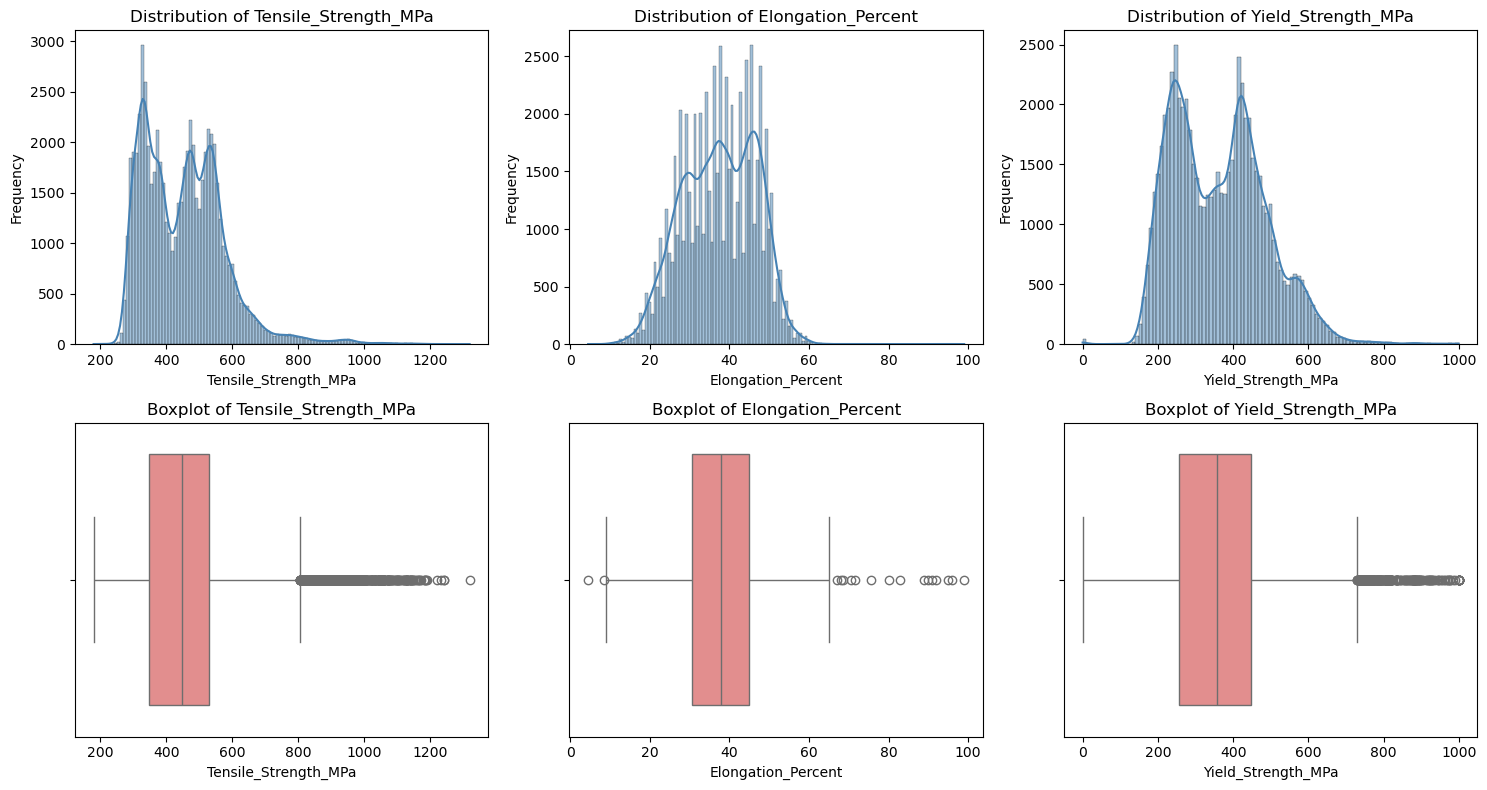

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

targets = ['Tensile_Strength_MPa', 'Elongation_Percent', 'Yield_Strength_MPa']

# Set up 2 rows × N targets (top row = histograms, bottom = boxplots)
fig, axes = plt.subplots(2, len(targets), figsize=(5 * len(targets), 8))

for i, col in enumerate(targets):
    # --- Histogram + KDE ---
    sns.histplot(combined_data[col], kde=True, ax=axes[0, i], color='steelblue')
    axes[0, i].set_title(f'Distribution of {col}', fontsize=12)
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frequency')

    # --- Boxplot ---
    sns.boxplot(x=combined_data[col], ax=axes[1, i], color='lightcoral')
    axes[1, i].set_title(f'Boxplot of {col}', fontsize=12)
    axes[1, i].set_xlabel(col)
    axes[1, i].set_ylabel('')

plt.tight_layout()
plt.show()



Analyzing: Tensile_Strength_MPa
count    65288.000000
mean       452.872886
std        122.946260
min        180.000000
25%        348.000000
50%        449.000000
75%        531.000000
max       1319.000000
Name: Tensile_Strength_MPa, dtype: float64

Skewness: 1.073
Kurtosis: 2.353

Shapiro-Wilk Test → Statistic=0.928, p-value=0.00000
⚠️ Data is likely non-normal (reject H₀)


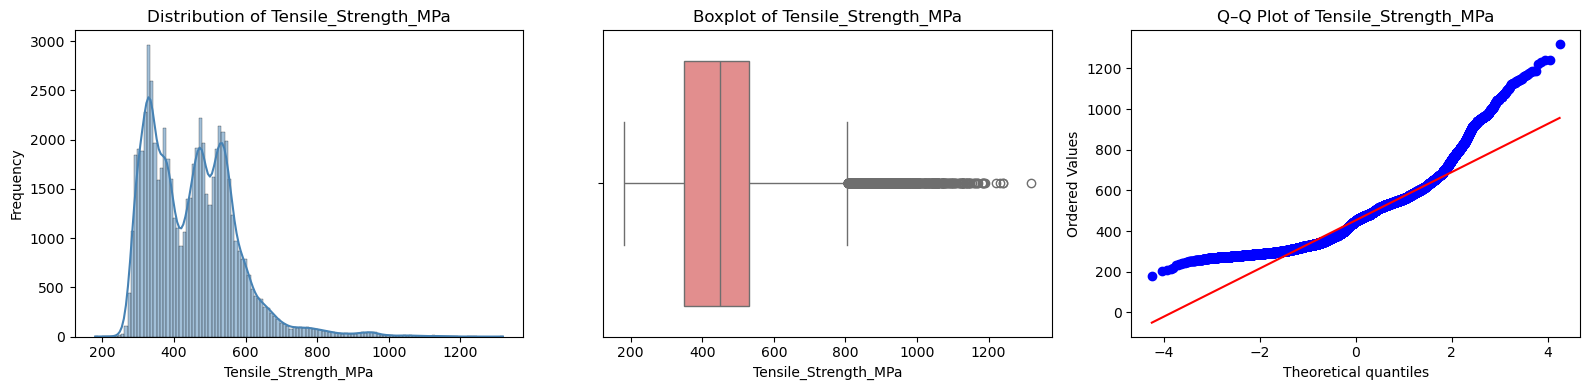


Outlier Range: [73.50, 805.50]
Number of outliers detected: 957 (1.47%)

Analyzing: Elongation_Percent
count    65288.000000
mean        37.544941
std          9.109712
min          4.500000
25%         30.500000
50%         38.000000
75%         45.000000
max         99.000000
Name: Elongation_Percent, dtype: float64

Skewness: -0.128
Kurtosis: -0.561

Shapiro-Wilk Test → Statistic=0.986, p-value=0.00000
⚠️ Data is likely non-normal (reject H₀)


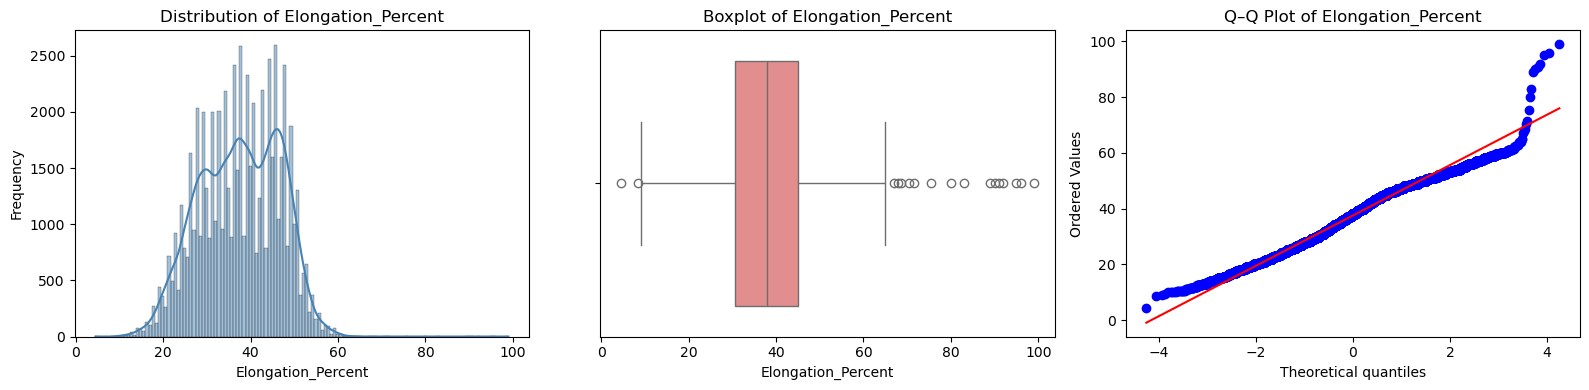


Outlier Range: [8.75, 66.75]
Number of outliers detected: 17 (0.03%)

Analyzing: Yield_Strength_MPa
count    65288.000000
mean       362.806366
std        122.746853
min          0.000000
25%        257.000000
50%        358.000000
75%        446.000000
max        999.000000
Name: Yield_Strength_MPa, dtype: float64

Skewness: 0.496
Kurtosis: -0.008

Shapiro-Wilk Test → Statistic=0.967, p-value=0.00000
⚠️ Data is likely non-normal (reject H₀)


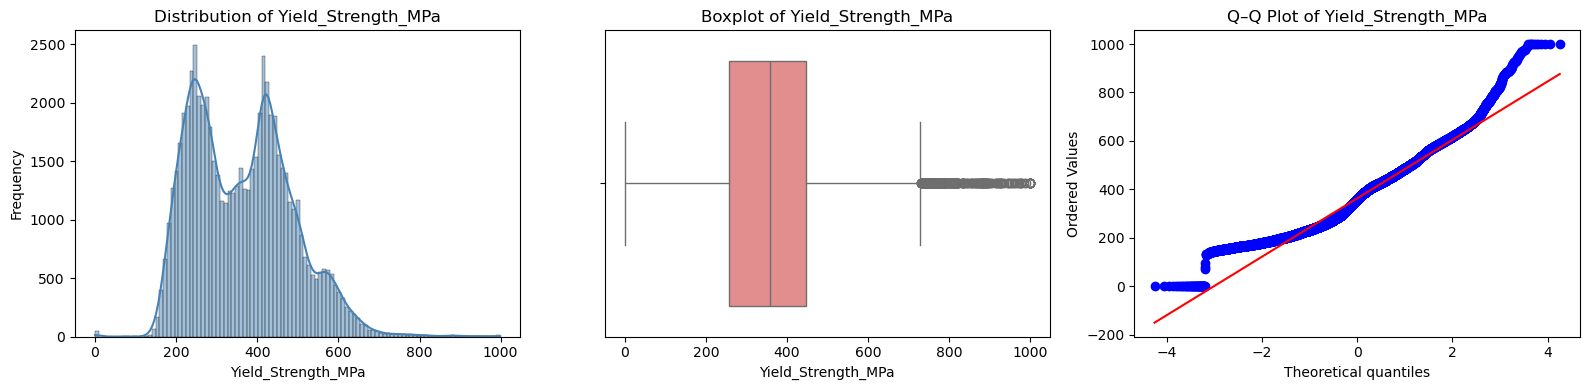


Outlier Range: [-26.50, 729.50]
Number of outliers detected: 264 (0.40%)


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

targets = ['Tensile_Strength_MPa', 'Elongation_Percent','Yield_Strength_MPa']

for col in targets:
    print(f"\n{'='*30}\nAnalyzing: {col}\n{'='*30}")
    
    # --- Descriptive Statistics ---
    desc = combined_data[col].describe()
    print(desc)
    print(f"\nSkewness: {combined_data[col].skew():.3f}")
    print(f"Kurtosis: {combined_data[col].kurtosis():.3f}")
    
    # --- Normality Test (Shapiro-Wilk) ---
    stat, p = stats.shapiro(combined_data[col].dropna())
    print(f"\nShapiro-Wilk Test → Statistic={stat:.3f}, p-value={p:.5f}")
    if p > 0.05:
        print("✅ Data appears normally distributed (fail to reject H₀)")
    else:
        print("⚠️ Data is likely non-normal (reject H₀)")
    
    # --- Visualizations ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # 1️⃣ Histogram + KDE
    sns.histplot(combined_data[col], kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title(f"Distribution of {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')
    
    # 2️⃣ Boxplot
    sns.boxplot(x=combined_data[col], ax=axes[1], color='lightcoral')
    axes[1].set_title(f"Boxplot of {col}")
    
    # 3️⃣ Q–Q Plot
    stats.probplot(combined_data[col].dropna(), dist="norm", plot=axes[2])
    axes[2].set_title(f"Q–Q Plot of {col}")
    
    plt.tight_layout()
    plt.show()
    
    # --- Outlier Detection (IQR Method) ---
    Q1 = combined_data[col].quantile(0.25)
    Q3 = combined_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = combined_data[(combined_data[col] < lower) | (combined_data[col] > upper)]
    
    print(f"\nOutlier Range: [{lower:.2f}, {upper:.2f}]")
    print(f"Number of outliers detected: {len(outliers)} ({100*len(outliers)/len(combined_data):.2f}%)")


## Correlation of target variables

=== Correlation Matrix Between Target Variables ===
                      Tensile_Strength_MPa  Elongation_Percent  \
Tensile_Strength_MPa                 1.000              -0.824   
Elongation_Percent                  -0.824               1.000   
Yield_Strength_MPa                   0.937              -0.837   

                      Yield_Strength_MPa  
Tensile_Strength_MPa               0.937  
Elongation_Percent                -0.837  
Yield_Strength_MPa                 1.000  


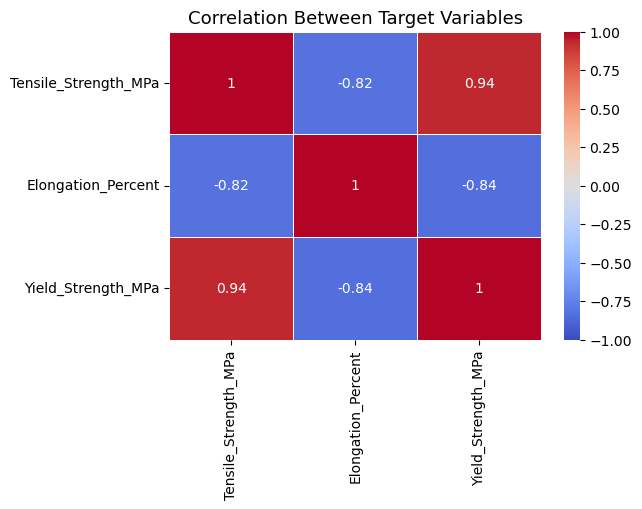

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define target variables
targets = ['Tensile_Strength_MPa', 'Elongation_Percent', 'Yield_Strength_MPa']

# Compute correlation matrix
target_corr = combined_data[targets].corr()

# Display correlation matrix
print("=== Correlation Matrix Between Target Variables ===")
print(target_corr.round(3))

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    target_corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('Correlation Between Target Variables', fontsize=13)
plt.show()


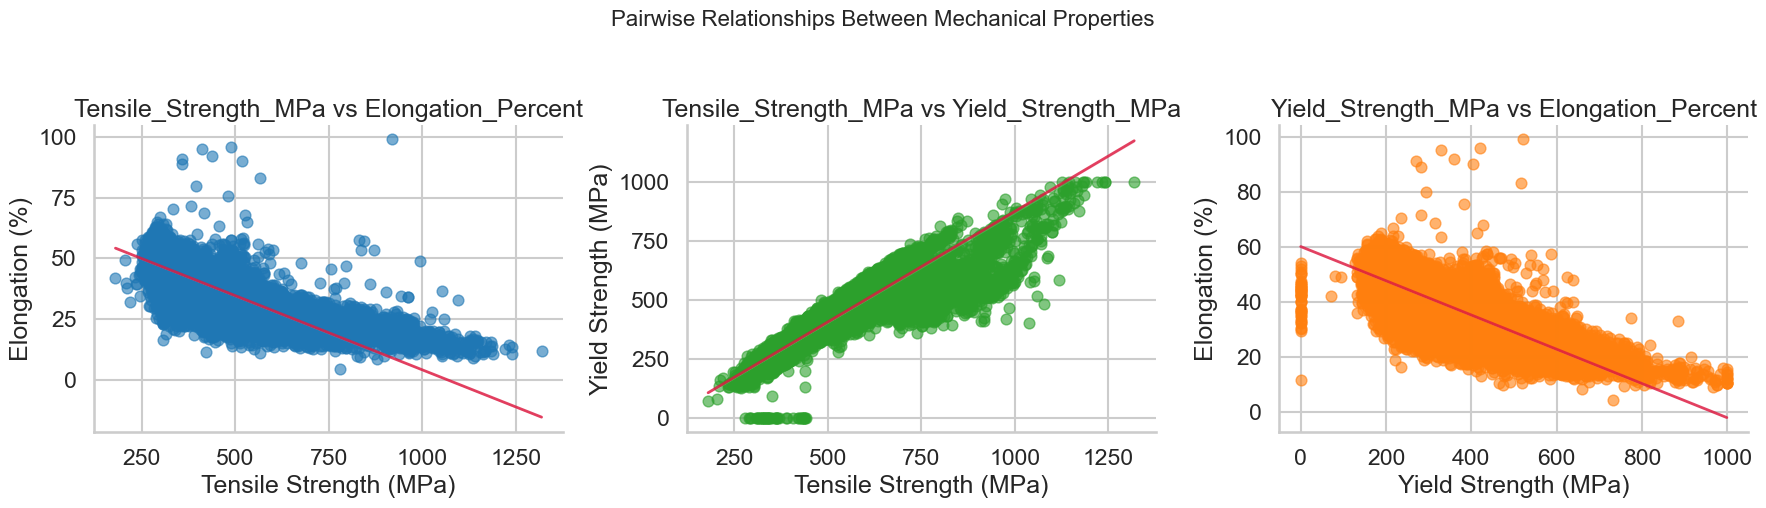

=== Correlation Matrix Between Target Variables ===
                      Tensile_Strength_MPa  Elongation_Percent  \
Tensile_Strength_MPa                 1.000              -0.824   
Elongation_Percent                  -0.824               1.000   
Yield_Strength_MPa                   0.937              -0.837   

                      Yield_Strength_MPa  
Tensile_Strength_MPa               0.937  
Elongation_Percent                -0.837  
Yield_Strength_MPa                 1.000  


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# Define target variables
t1 = 'Tensile_Strength_MPa'
t2 = 'Elongation_Percent'
t3 = 'Yield_Strength_MPa'

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1️⃣ Tensile vs Elongation
sns.regplot(
    x=t1, y=t2, data=combined_data,
    scatter_kws={"alpha": 0.6, "s": 60, "color": "#1f77b4"},
    line_kws={"color": "crimson", "lw": 2, "alpha": 0.8},
    ax=axes[0]
)
axes[0].set_title(f'{t1} vs {t2}')
axes[0].set_xlabel('Tensile Strength (MPa)')
axes[0].set_ylabel('Elongation (%)')

# 2️⃣ Tensile vs Yield
sns.regplot(
    x=t1, y=t3, data=combined_data,
    scatter_kws={"alpha": 0.6, "s": 60, "color": "#2ca02c"},
    line_kws={"color": "crimson", "lw": 2, "alpha": 0.8},
    ax=axes[1]
)
axes[1].set_title(f'{t1} vs {t3}')
axes[1].set_xlabel('Tensile Strength (MPa)')
axes[1].set_ylabel('Yield Strength (MPa)')

# 3️⃣ Yield vs Elongation
sns.regplot(
    x=t3, y=t2, data=combined_data,
    scatter_kws={"alpha": 0.6, "s": 60, "color": "#ff7f0e"},
    line_kws={"color": "crimson", "lw": 2, "alpha": 0.8},
    ax=axes[2]
)
axes[2].set_title(f'{t3} vs {t2}')
axes[2].set_xlabel('Yield Strength (MPa)')
axes[2].set_ylabel('Elongation (%)')

# Layout polish
plt.suptitle('Pairwise Relationships Between Mechanical Properties', fontsize=16, y=1.03)
plt.tight_layout()
sns.despine()
plt.show()

# Display correlation matrix
print("=== Correlation Matrix Between Target Variables ===")
print(target_corr.round(3))

## Bivariate Analysis, features vs target

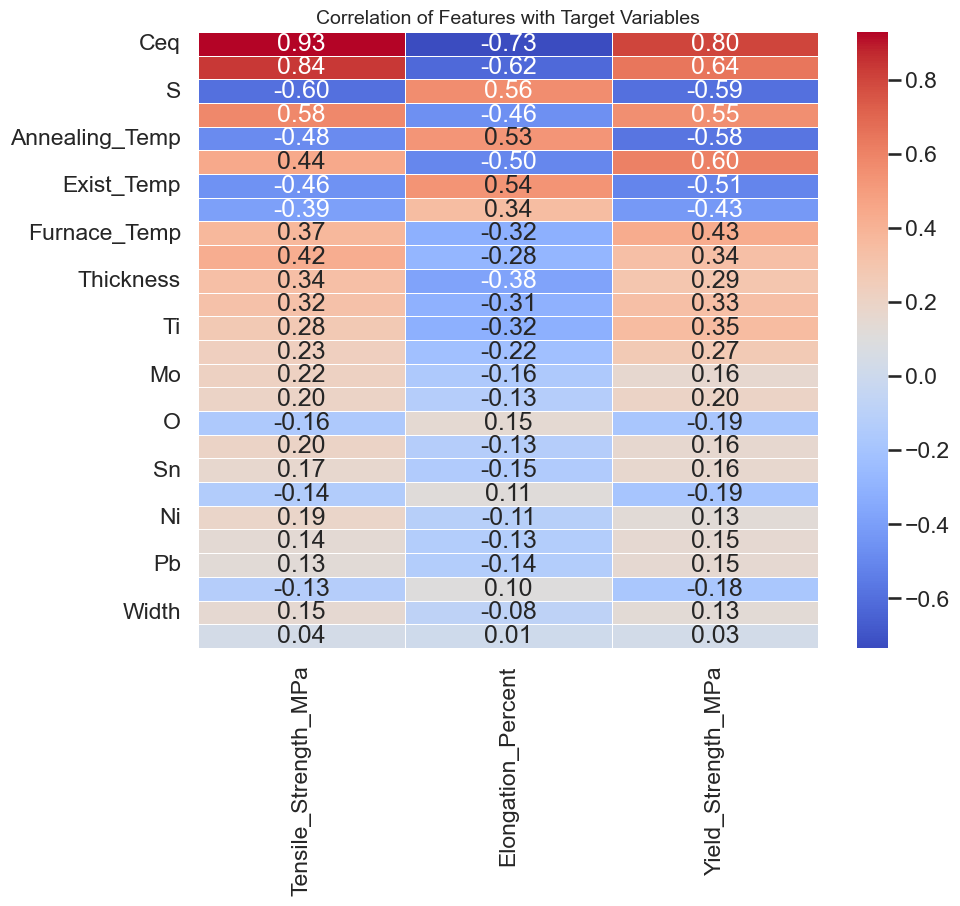

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of features and targets
features = [
    'Furnace_Temp', 'Exist_Temp', 'Annealing_Temp', 'Thickness', 'Width', 'S','Cu','Ni', 
    'Cr', 'Mo', 'V', 'Nb', 'Al', 'Acid Sol. Al', 'Ti', 'B', 'Sn', 'As', 'Zr', 'Ca', 'Pb', 'Ceq', 'Pcm', 'Sb', 'N', 'O'
]
targets = ['Tensile_Strength_MPa', 'Elongation_Percent','Yield_Strength_MPa']

# Compute correlation matrix
corr_matrix = combined_data[features + targets].corr()

# Extract only correlations of features with targets
target_corr = corr_matrix[targets].loc[features]

# Sort features by average absolute correlation across all targets (descending)
sorted_features = target_corr.abs().mean(axis=1).sort_values(ascending=False).index
target_corr_sorted = target_corr.loc[sorted_features]

# Plot the same heatmap style, now sorted
plt.figure(figsize=(10, 8))
sns.heatmap(target_corr_sorted, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation of Features with Target Variables", fontsize=14)
plt.show()


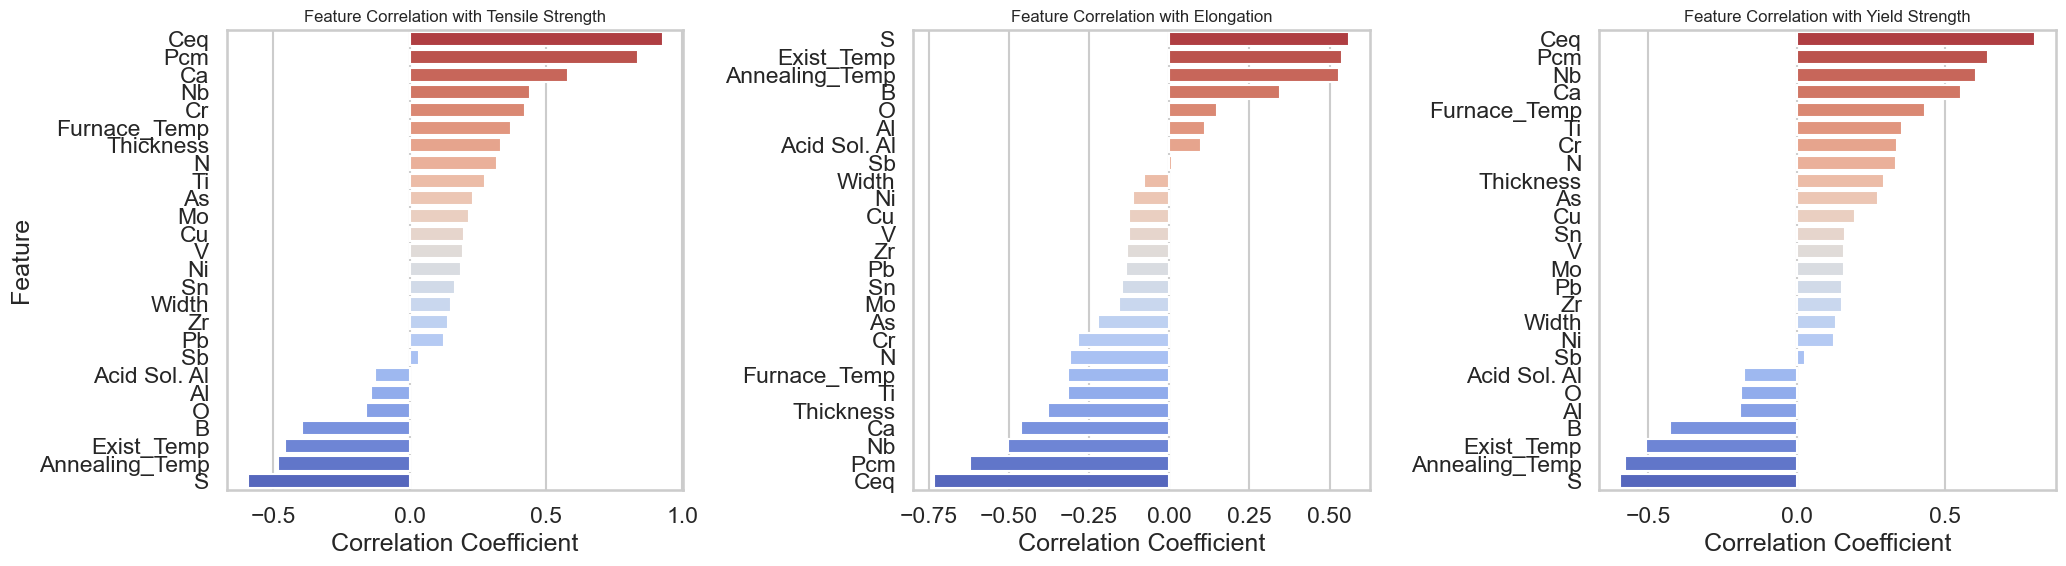

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of features and targets
features = [
    'Furnace_Temp', 'Exist_Temp', 'Annealing_Temp', 'Thickness', 'Width', 'S','Cu','Ni', 
    'Cr', 'Mo', 'V', 'Nb', 'Al', 'Acid Sol. Al', 'Ti', 'B', 'Sn', 'As', 'Zr', 'Ca', 'Pb', 'Ceq', 'Pcm', 'Sb', 'N', 'O'
]
targets = ['Tensile_Strength_MPa', 'Elongation_Percent', 'Yield_Strength_MPa']

# Compute correlation matrix
corr_matrix = combined_data[features + targets].corr()

# Extract only correlations of features with targets
target_corr = corr_matrix[targets].loc[features]

# Sort correlations for each target individually
sorted_strength = target_corr['Tensile_Strength_MPa'].sort_values(ascending=False)
sorted_elong = target_corr['Elongation_Percent'].sort_values(ascending=False)
sorted_yield = target_corr['Yield_Strength_MPa'].sort_values(ascending=False)

# Create 3 subplots (side-by-side)
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# --- Tensile Strength ---
sns.barplot(
    x=sorted_strength.values,
    y=sorted_strength.index,
    ax=axes[0],
    palette='coolwarm_r'
)
axes[0].set_title('Feature Correlation with Tensile Strength', fontsize=12)
axes[0].set_xlabel('Correlation Coefficient')
axes[0].set_ylabel('Feature')

# --- Elongation ---
sns.barplot(
    x=sorted_elong.values,
    y=sorted_elong.index,
    ax=axes[1],
    palette='coolwarm_r'
)
axes[1].set_title('Feature Correlation with Elongation', fontsize=12)
axes[1].set_xlabel('Correlation Coefficient')
axes[1].set_ylabel('')

# --- Yield Strength ---
sns.barplot(
    x=sorted_yield.values,
    y=sorted_yield.index,
    ax=axes[2],
    palette='coolwarm_r'
)
axes[2].set_title('Feature Correlation with Yield Strength', fontsize=12)
axes[2].set_xlabel('Correlation Coefficient')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()


Top correlated features with Tensile Strength: ['Ceq', 'Pcm', 'S', 'Ca', 'Annealing_Temp']
Top correlated features with Elongation: ['Ceq', 'Pcm', 'S', 'Exist_Temp', 'Annealing_Temp']


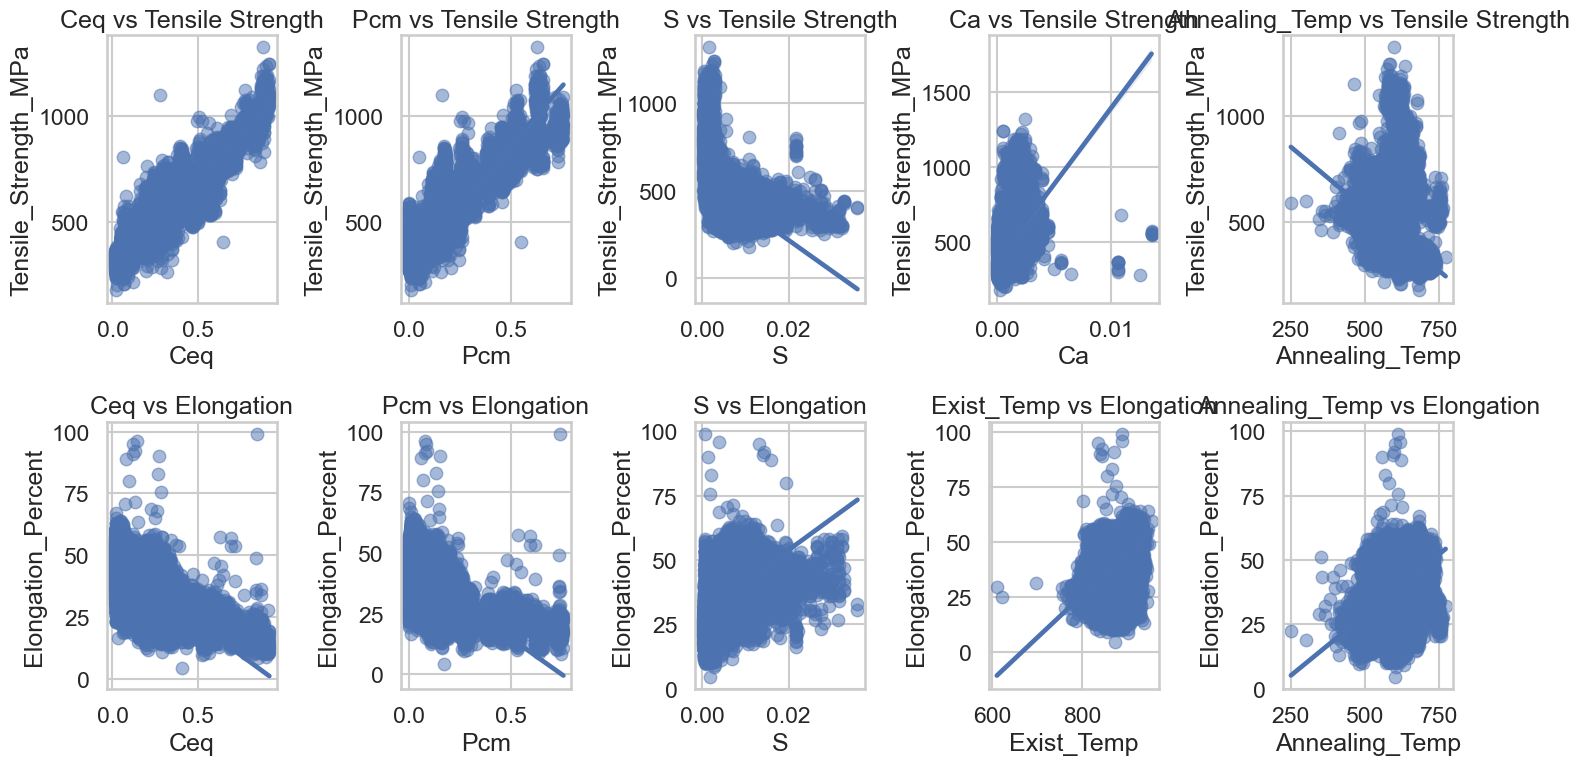

In [24]:
# Find top 5 correlations for each target
top_strength = target_corr['Tensile_Strength_MPa'].abs().sort_values(ascending=False).head(5).index
top_elong = target_corr['Elongation_Percent'].abs().sort_values(ascending=False).head(5).index

print("Top correlated features with Tensile Strength:", list(top_strength))
print("Top correlated features with Elongation:", list(top_elong))

# Scatterplots
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
for i, feat in enumerate(top_strength):
    sns.regplot(x=feat, y='Tensile_Strength_MPa', data=combined_data, ax=axes[0, i], scatter_kws={'alpha':0.5})
    axes[0, i].set_title(f'{feat} vs Tensile Strength')

for i, feat in enumerate(top_elong):
    sns.regplot(x=feat, y='Elongation_Percent', data=combined_data, ax=axes[1, i], scatter_kws={'alpha':0.5})
    axes[1, i].set_title(f'{feat} vs Elongation')

plt.tight_layout()
plt.show()


## Heatmap of all variables

In [25]:
processing_parameters = ['Furnace_Temp', 'Exist_Temp', 'Annealing_Temp', 'Thickness', 'Width']
chem_comp = ['S','Cu','Ni','Cr', 'Mo', 'V', 'Nb', 'Al', 'Acid Sol. Al', 'Ti', 'B', 'Sn', 'As', 'Zr', 'Ca', 'Pb', 'Ceq', 'Pcm', 'Sb','N','O']

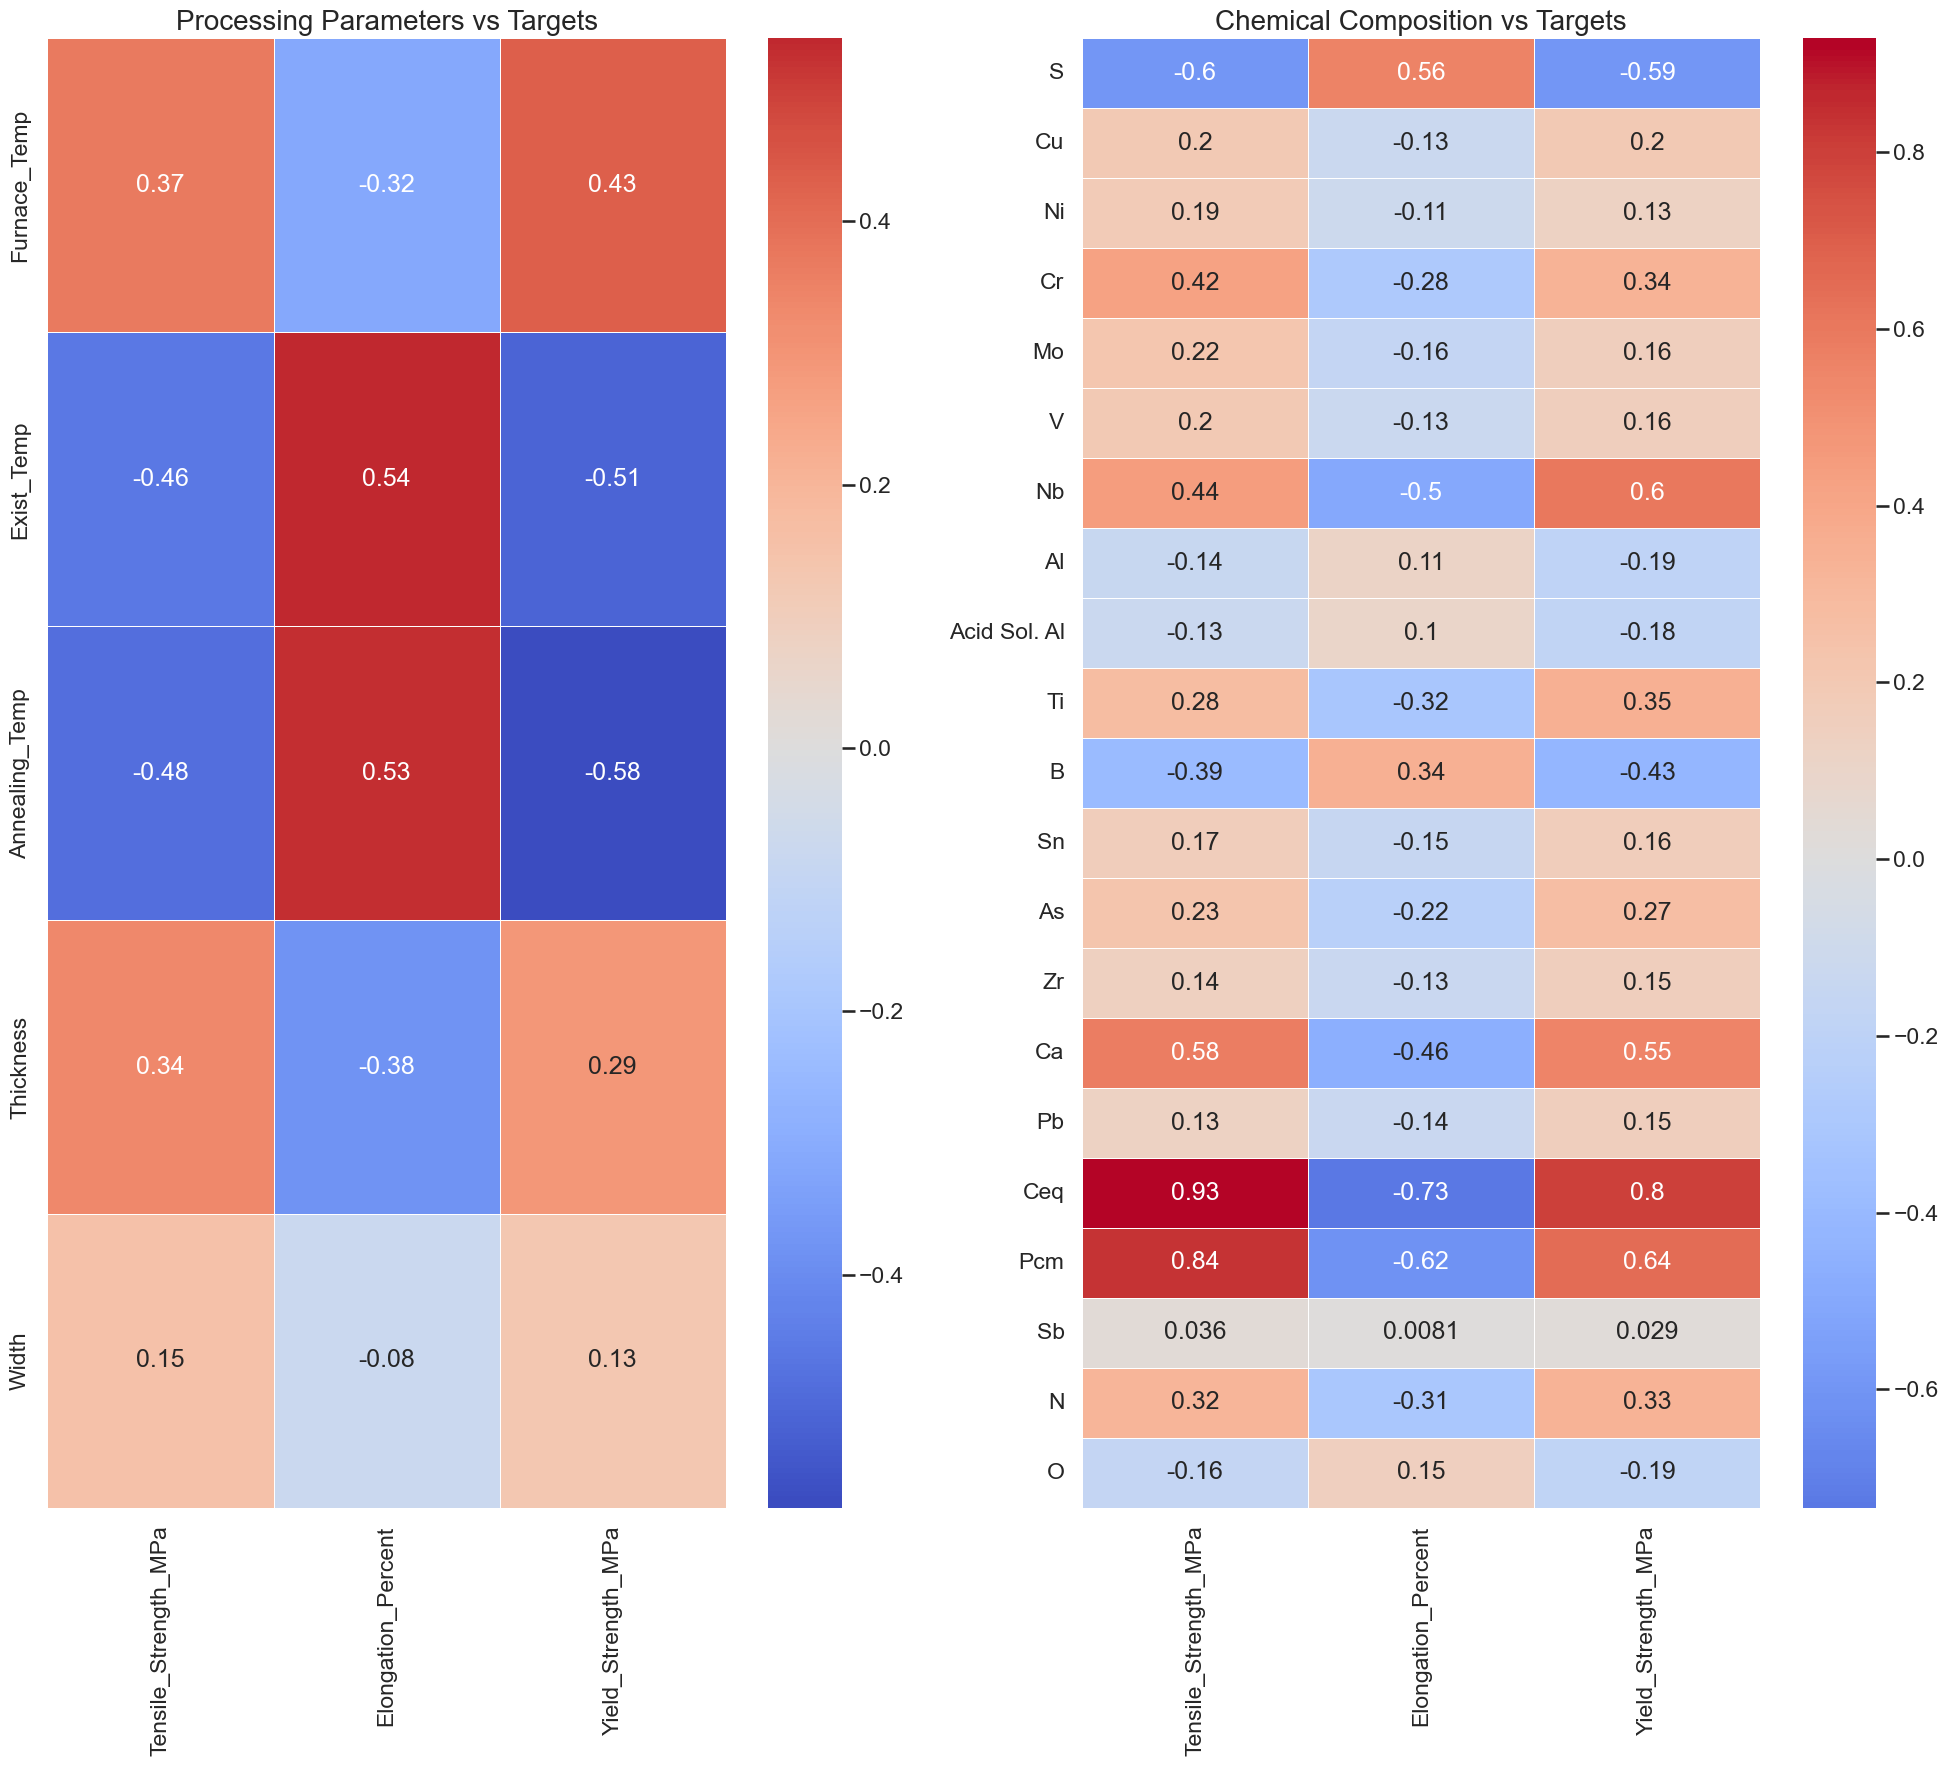

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrices
corr_proc = combined_data[processing_parameters + targets].corr()[targets].loc[processing_parameters]
corr_chem = combined_data[chem_comp + targets].corr()[targets].loc[chem_comp]

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 18))

sns.heatmap(corr_proc, annot=True, cmap='coolwarm', center=0, linewidths=0.5, ax=axes[0])
axes[0].set_title('Processing Parameters vs Targets', fontsize=20)

sns.heatmap(corr_chem, annot=True, cmap='coolwarm', center=0, linewidths=0.5, ax=axes[1])
axes[1].set_title('Chemical Composition vs Targets', fontsize=20)

plt.tight_layout()
plt.show()


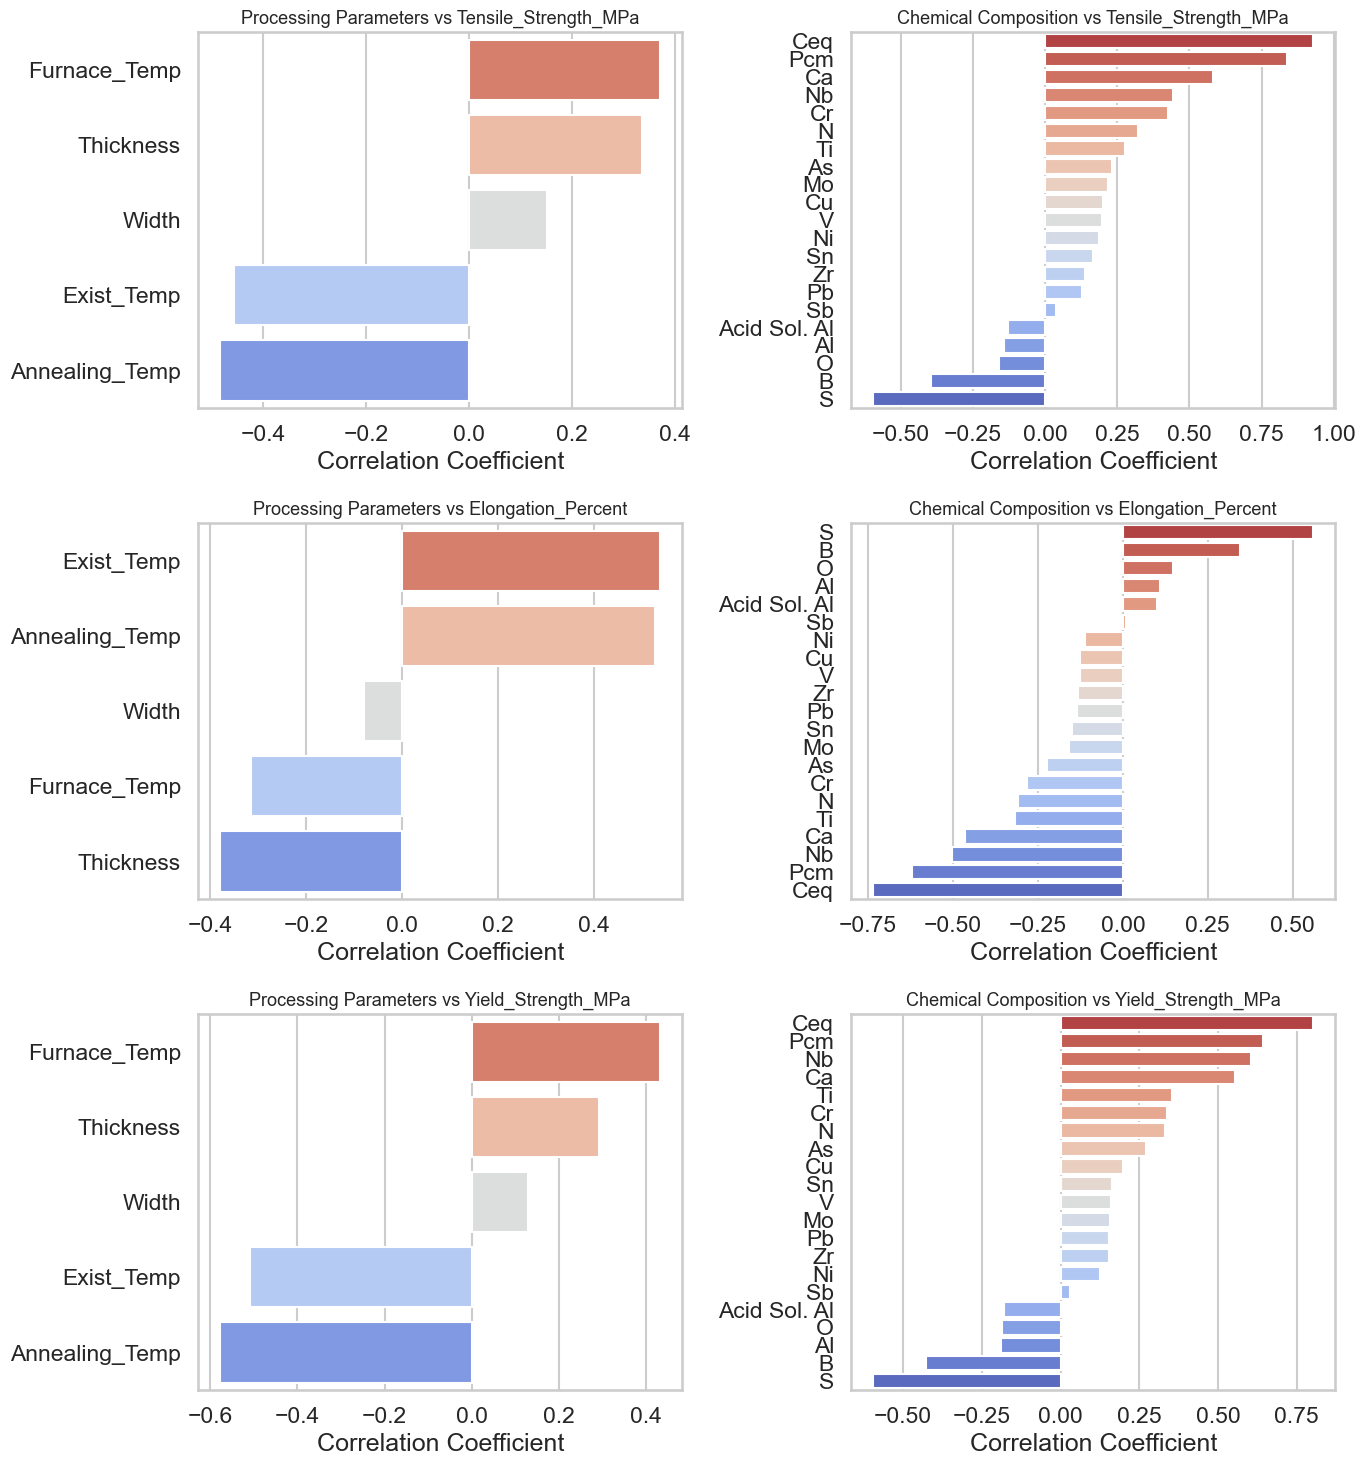

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define feature groups
processing_parameters = ['Furnace_Temp', 'Exist_Temp', 'Annealing_Temp', 'Thickness', 'Width']
chem_comp = ['S','Cu','Ni','Cr', 'Mo', 'V', 'Nb', 'Al', 'Acid Sol. Al', 'Ti', 'B', 'Sn', 'As', 'Zr', 'Ca', 'Pb', 'Ceq', 'Pcm', 'Sb','N','O']
targets = ['Tensile_Strength_MPa', 'Elongation_Percent', 'Yield_Strength_MPa']

# Compute correlation matrices
corr_proc = combined_data[processing_parameters + targets].corr()[targets].loc[processing_parameters]
corr_chem = combined_data[chem_comp + targets].corr()[targets].loc[chem_comp]

# Create one figure with subplots for each target
fig, axes = plt.subplots(len(targets), 2, figsize=(14, 5 * len(targets)))

for i, t in enumerate(targets):
    # --- Processing Parameters ---
    sorted_proc = corr_proc[t].sort_values(ascending=False)
    sns.barplot(x=sorted_proc.values, y=sorted_proc.index, palette='coolwarm_r', ax=axes[i, 0])
    axes[i, 0].set_title(f'Processing Parameters vs {t}', fontsize=13)
    axes[i, 0].set_xlabel('Correlation Coefficient')
    axes[i, 0].set_ylabel('')
    
    # --- Chemical Composition ---
    sorted_chem = corr_chem[t].sort_values(ascending=False)
    sns.barplot(x=sorted_chem.values, y=sorted_chem.index, palette='coolwarm_r', ax=axes[i, 1])
    axes[i, 1].set_title(f'Chemical Composition vs {t}', fontsize=13)
    axes[i, 1].set_xlabel('Correlation Coefficient')
    axes[i, 1].set_ylabel('')

plt.tight_layout()
plt.show()


In [28]:
# Define all features and target variables
features = [
    'Furnace_Temp', 'Exist_Temp', 'Annealing_Temp', 'Thickness', 'Width', 'S','Cu','Ni', 
    'Cr', 'Mo', 'V', 'Nb', 'Al', 'Acid Sol. Al', 'Ti', 'B', 'Sn', 'As', 'Zr', 'Ca', 'Pb', 'Ceq', 'Pcm', 'Sb', 'N', 'O'
]
targets = ['Tensile_Strength_MPa', 'Elongation_Percent', 'Yield_Strength_MPa']

# Compute correlation matrix
corr_matrix = combined_data[features + targets].corr()

# Extract correlations of features with targets
target_corr = corr_matrix[targets].loc[features]

# Print top 5 features for each target
for t in targets:
    print(f"\n=== Top 5 Variables Affecting {t} (Descending by |Correlation|) ===")
    top5 = target_corr[t].abs().sort_values(ascending=False).head(5)
    print(top5)



=== Top 5 Variables Affecting Tensile_Strength_MPa (Descending by |Correlation|) ===
Ceq               0.928984
Pcm               0.836945
S                 0.595286
Ca                0.582107
Annealing_Temp    0.482765
Name: Tensile_Strength_MPa, dtype: float64

=== Top 5 Variables Affecting Elongation_Percent (Descending by |Correlation|) ===
Ceq               0.734370
Pcm               0.620188
S                 0.560197
Exist_Temp        0.538910
Annealing_Temp    0.528930
Name: Elongation_Percent, dtype: float64

=== Top 5 Variables Affecting Yield_Strength_MPa (Descending by |Correlation|) ===
Ceq               0.802225
Pcm               0.644080
Nb                0.604291
S                 0.594265
Annealing_Temp    0.577133
Name: Yield_Strength_MPa, dtype: float64


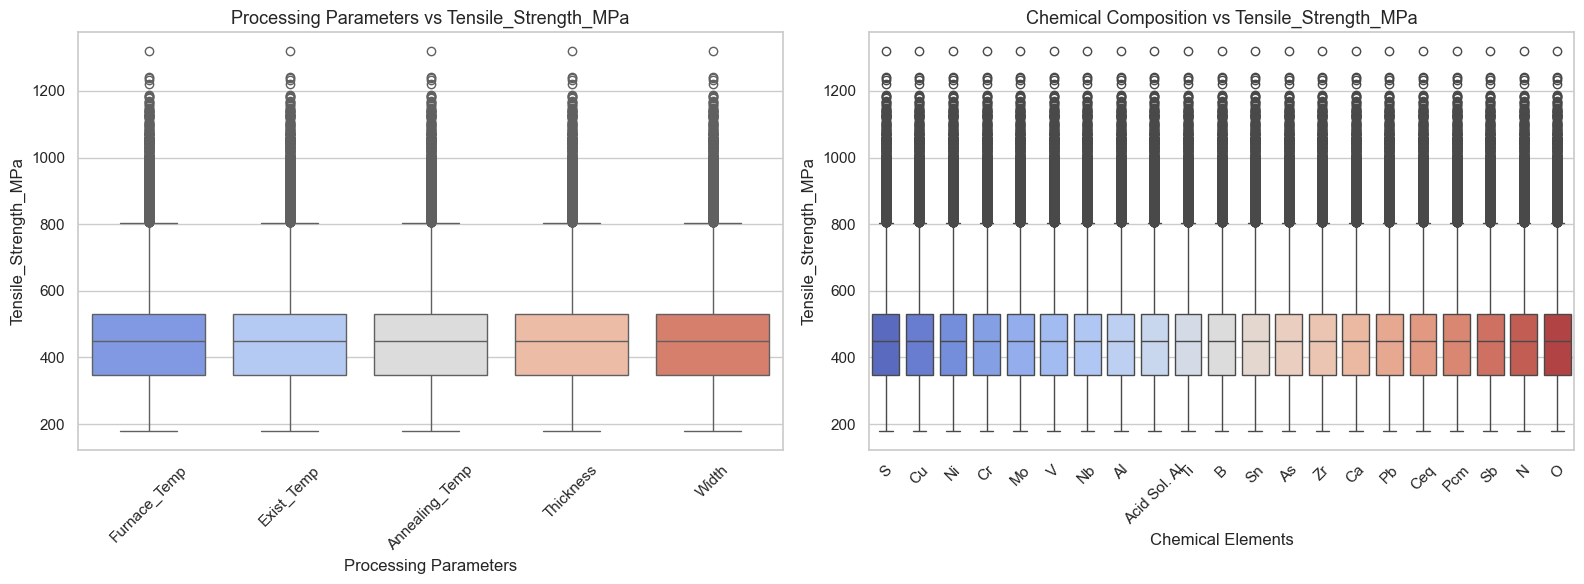

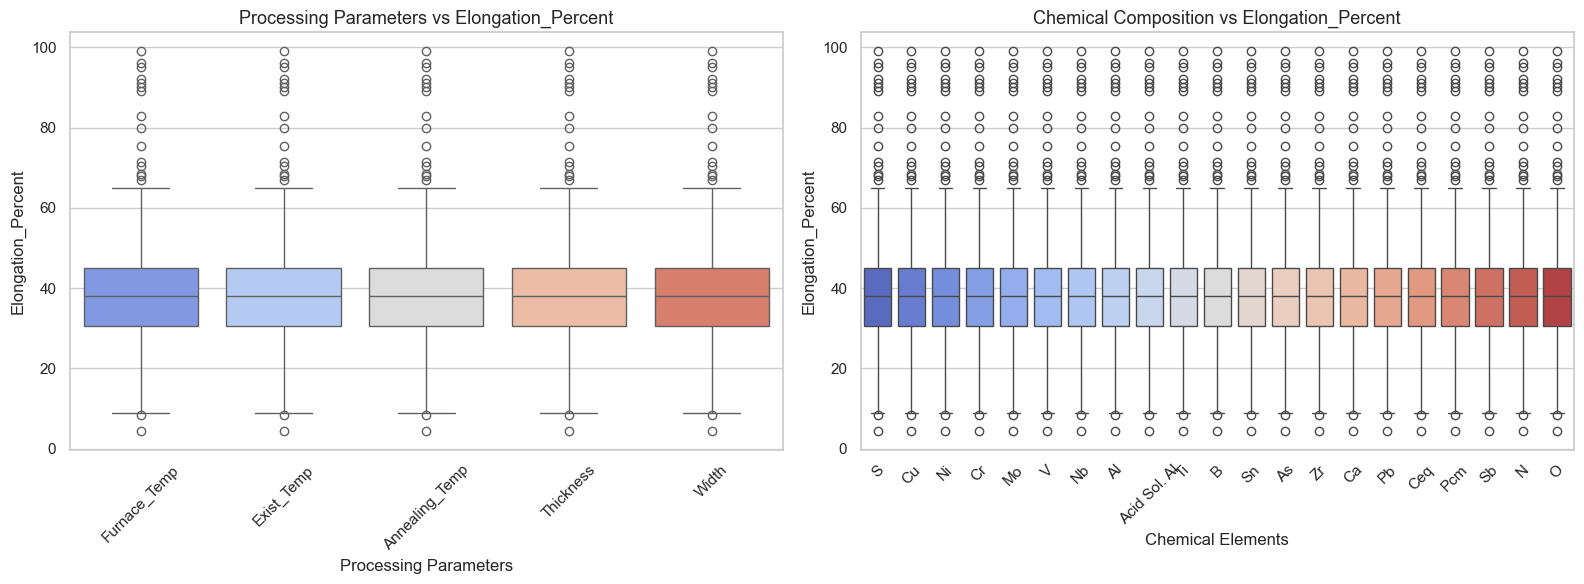

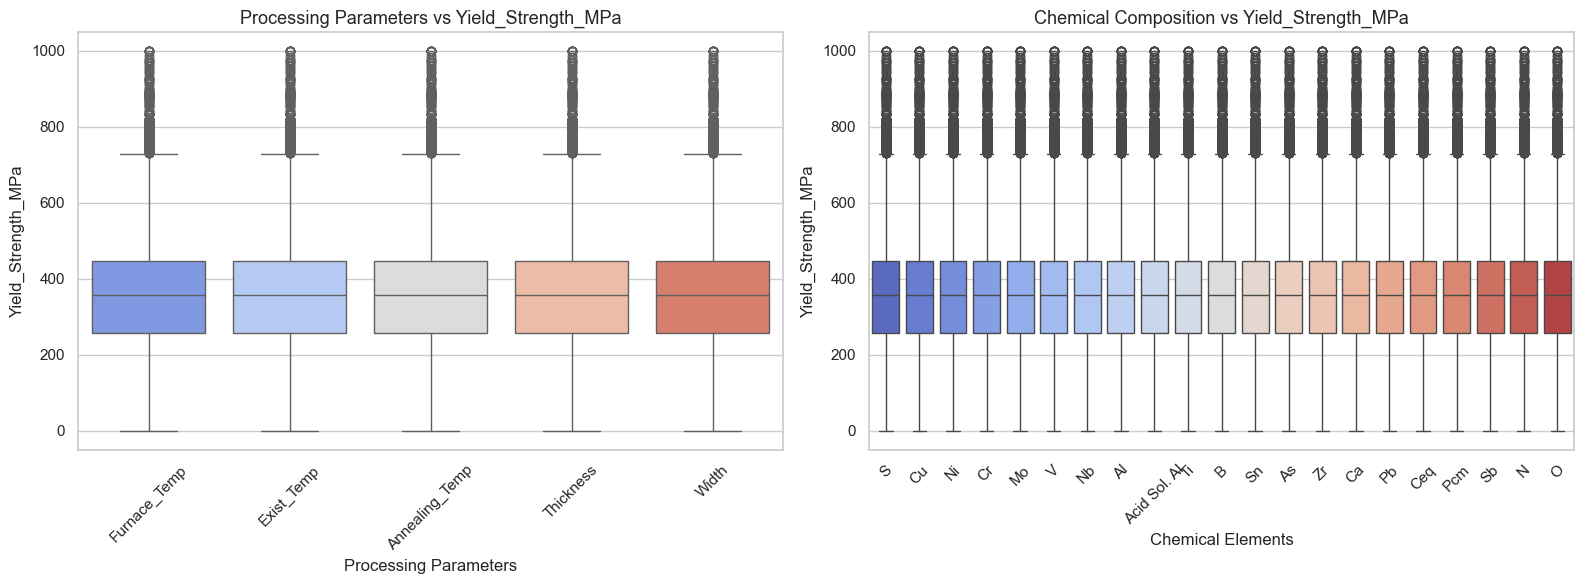

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define your feature groups
processing_parameters = ['Furnace_Temp', 'Exist_Temp', 'Annealing_Temp', 'Thickness', 'Width']
chem_comp = ['S','Cu','Ni','Cr', 'Mo', 'V', 'Nb', 'Al', 'Acid Sol. Al', 'Ti', 'B', 'Sn', 'As', 'Zr', 'Ca', 'Pb', 'Ceq', 'Pcm', 'Sb','N','O']
targets = ['Tensile_Strength_MPa', 'Elongation_Percent', 'Yield_Strength_MPa']

# Set plotting style
sns.set(style="whitegrid")

# Create boxplots for each category
for t in targets:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Processing parameters vs target
    sns.boxplot(
        data=combined_data[processing_parameters + [t]].melt(id_vars=t),
        x='variable', y=t, ax=axes[0], palette='coolwarm'
    )
    axes[0].set_title(f'Processing Parameters vs {t}', fontsize=13)
    axes[0].set_xlabel('Processing Parameters')
    axes[0].set_ylabel(t)
    axes[0].tick_params(axis='x', rotation=45)
    
    # Chemical composition vs target
    sns.boxplot(
        data=combined_data[chem_comp + [t]].melt(id_vars=t),
        x='variable', y=t, ax=axes[1], palette='coolwarm'
    )
    axes[1].set_title(f'Chemical Composition vs {t}', fontsize=13)
    axes[1].set_xlabel('Chemical Elements')
    axes[1].set_ylabel(t)
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()


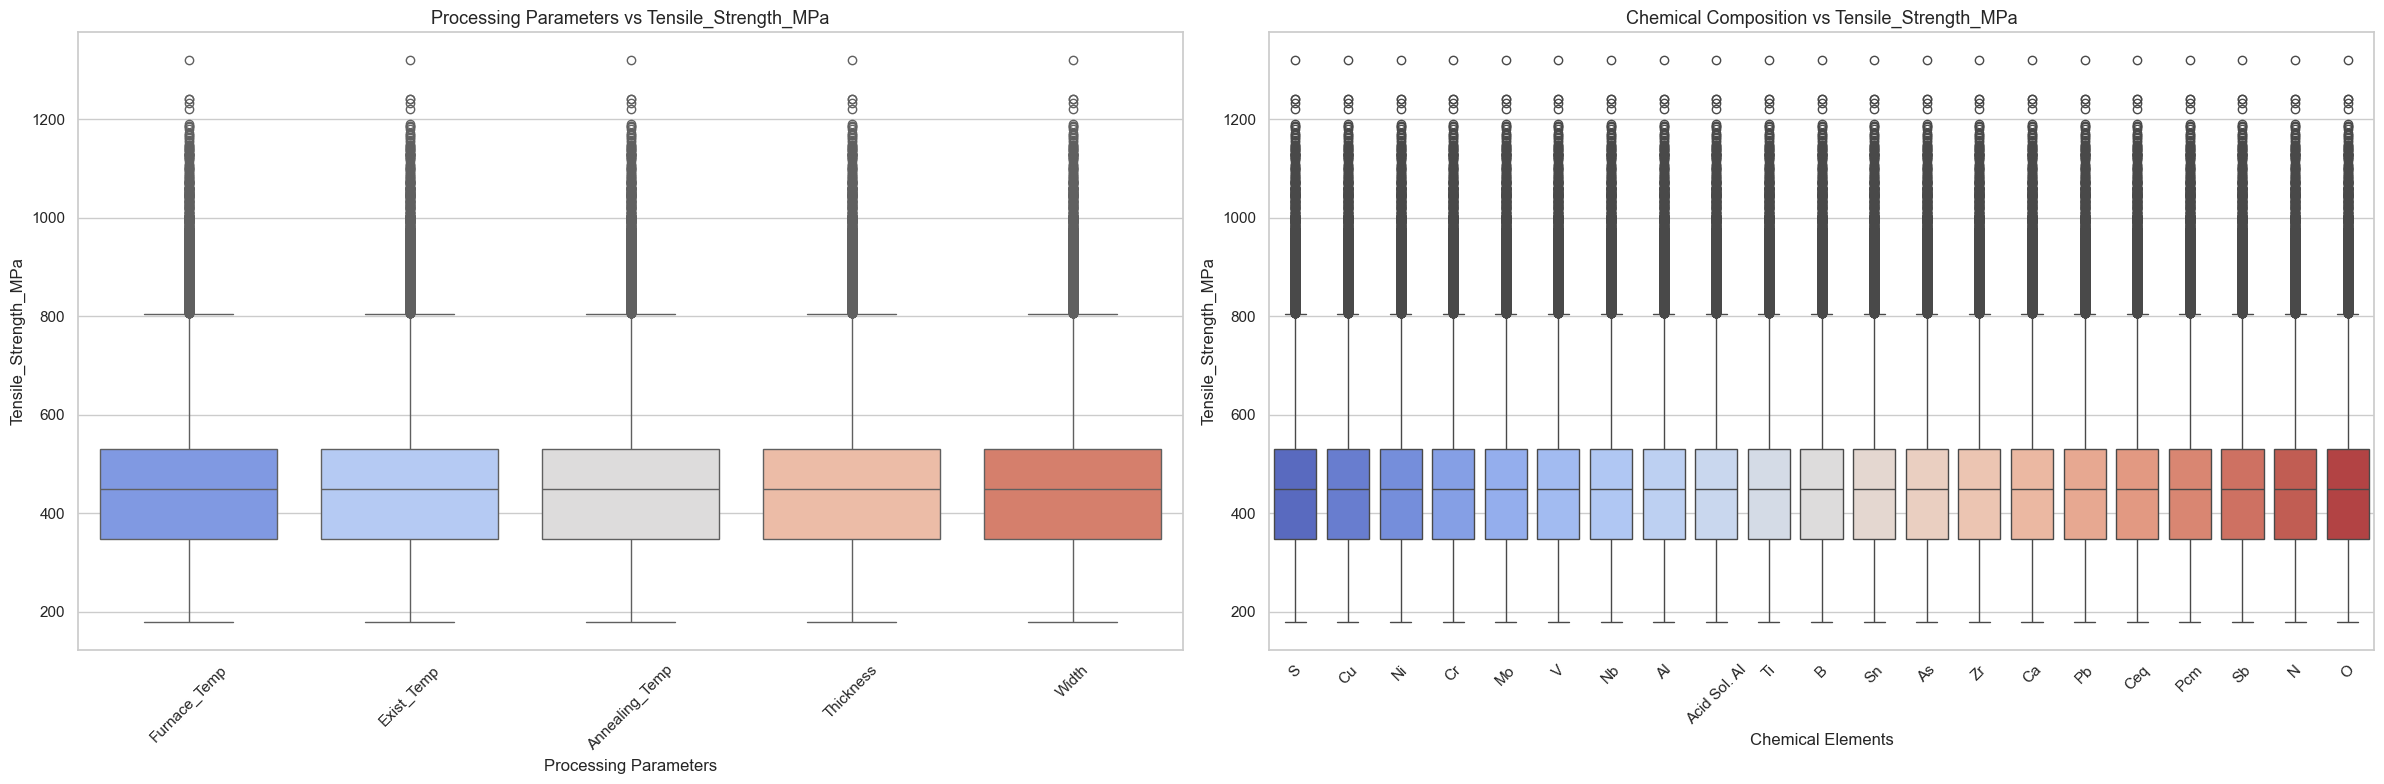

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define feature groups
processing_parameters = ['Furnace_Temp', 'Exist_Temp', 'Annealing_Temp', 'Thickness', 'Width']
chem_comp = ['S','Cu','Ni','Cr', 'Mo', 'V', 'Nb', 'Al', 'Acid Sol. Al', 'Ti', 'B', 'Sn', 'As', 'Zr', 'Ca', 'Pb', 'Ceq', 'Pcm', 'Sb','N','O']

# Target variable
target = 'Tensile_Strength_MPa'

# Plot style
sns.set(style="whitegrid")

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(24, 8))

# --- Processing parameters vs Tensile Strength ---
sns.boxplot(
    data=combined_data[processing_parameters + [target]].melt(id_vars=target),
    x='variable', y=target, ax=axes[0], palette='coolwarm'
)
axes[0].set_title(f'Processing Parameters vs {target}', fontsize=13)
axes[0].set_xlabel('Processing Parameters')
axes[0].set_ylabel(target)
axes[0].tick_params(axis='x', rotation=45)

# --- Chemical composition vs Tensile Strength ---
sns.boxplot(
    data=combined_data[chem_comp + [target]].melt(id_vars=target),
    x='variable', y=target, ax=axes[1], palette='coolwarm'
)
axes[1].set_title(f'Chemical Composition vs {target}', fontsize=13)
axes[1].set_xlabel('Chemical Elements')
axes[1].set_ylabel(target)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## Train & Test Model

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor, RegressorChain
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Define features and targets ===
features = [
    'Furnace_Temp', 'Exist_Temp', 'Annealing_Temp', 'Thickness', 'Width', 'S','Cu','Ni', 
    'Cr', 'Mo', 'V', 'Nb', 'Al', 'Acid Sol. Al', 'Ti', 'B', 'Sn', 'As', 'Zr', 'Ca', 'Pb', 'Ceq', 'Pcm', 'Sb','N','O'
]
targets = ['Tensile_Strength_MPa','Elongation_Percent','Yield_Strength_MPa']

# === Split data ===
df = combined_data.dropna(subset=features + targets)
X = df[features]
Y = df[targets]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [32]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0, random_state=42))
])

ridge_multi = MultiOutputRegressor(ridge_model)
ridge_multi.fit(X_train, Y_train)
Y_pred = ridge_multi.predict(X_test)

# Metrics
for i, t in enumerate(targets):
    r2  = r2_score(Y_test.iloc[:, i], Y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(Y_test.iloc[:, i], Y_pred[:, i]))
    print(f"{t}: R²={r2:.3f} | RMSE={rmse:.3f}")


Tensile_Strength_MPa: R²=0.937 | RMSE=31.189
Elongation_Percent: R²=0.730 | RMSE=4.743
Yield_Strength_MPa: R²=0.881 | RMSE=42.286


In [33]:
from sklearn.ensemble import RandomForestRegressor

rf_multi = RandomForestRegressor(
    n_estimators=300, random_state=42, n_jobs=-1
)
rf_multi.fit(X_train, Y_train)
Y_pred = rf_multi.predict(X_test)

for i, t in enumerate(targets):
    r2  = r2_score(Y_test.iloc[:, i], Y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(Y_test.iloc[:, i], Y_pred[:, i]))
    print(f"{t}: R²={r2:.3f} | RMSE={rmse:.3f}")


Tensile_Strength_MPa: R²=0.965 | RMSE=23.067
Elongation_Percent: R²=0.818 | RMSE=3.896
Yield_Strength_MPa: R²=0.940 | RMSE=30.076


In [35]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 9.7 MB/s eta 0:00:11
   -- ------------------------------------- 5.8/101.7 MB 17.1 MB/s eta 0:00:06
   ----- ---------------------------------- 13.6/101.7 MB 24.7 MB/s eta 0:00:04
   -------- ------------------------------- 22.3/101.7 MB 29.0 MB/s eta 0:00:03
   ------------ --------------------------- 31.5/101.7 MB 32.1 MB/s eta 0:00:03
   --------------- ------------------------ 39.6/101.7 MB 33.7 MB/s eta 0:00:02
   ------------------- -------------------- 49.8/101.7 MB 35.4 MB/s eta 0:00:02
   ----------------------- ---------------- 59.8/101.7 MB 36.9 MB/s eta 0:00:02
   --------------------------- ------------ 70.0/101.7 MB 38.1 MB/s eta 0:00:01
   ------------------------------- -------- 79.4/101.7 MB 38.7 MB/s eta 0:00:01
   ---------------------------------- ----- 88.6/101.7 MB 39.2 MB/s eta 0:00:01
   -------------------------------------- - 98.3/101

In [36]:
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

xgb_multi = MultiOutputRegressor(
    XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1
    )
)
xgb_multi.fit(X_train, Y_train)
Y_pred = xgb_multi.predict(X_test)

for i, t in enumerate(targets):
    r2  = r2_score(Y_test.iloc[:, i], Y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(Y_test.iloc[:, i], Y_pred[:, i]))
    print(f"{t}: R²={r2:.3f} | RMSE={rmse:.3f}")


Tensile_Strength_MPa: R²=0.964 | RMSE=23.414
Elongation_Percent: R²=0.827 | RMSE=3.800
Yield_Strength_MPa: R²=0.939 | RMSE=30.326


In [37]:
from sklearn.svm import SVR

svr_multi = MultiOutputRegressor(
    Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVR(kernel='rbf', C=10, epsilon=0.1))
    ])
)
svr_multi.fit(X_train, Y_train)
Y_pred = svr_multi.predict(X_test)

for i, t in enumerate(targets):
    r2  = r2_score(Y_test.iloc[:, i], Y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(Y_test.iloc[:, i], Y_pred[:, i]))
    print(f"{t}: R²={r2:.3f} | RMSE={rmse:.3f}")

Tensile_Strength_MPa: R²=0.955 | RMSE=26.300
Elongation_Percent: R²=0.801 | RMSE=4.072
Yield_Strength_MPa: R²=0.926 | RMSE=33.421


In [38]:
from sklearn.neighbors import KNeighborsRegressor

knn_multi = MultiOutputRegressor(
    Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsRegressor(n_neighbors=10, weights='distance'))
    ])
)
knn_multi.fit(X_train, Y_train)
Y_pred = knn_multi.predict(X_test)

for i, t in enumerate(targets):
    r2  = r2_score(Y_test.iloc[:, i], Y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(Y_test.iloc[:, i], Y_pred[:, i]))
    print(f"{t}: R²={r2:.3f} | RMSE={rmse:.3f}")


Tensile_Strength_MPa: R²=0.960 | RMSE=24.658
Elongation_Percent: R²=0.803 | RMSE=4.057
Yield_Strength_MPa: R²=0.932 | RMSE=32.028


In [39]:
from sklearn.neural_network import MLPRegressor

ann_multi = MultiOutputRegressor(
    Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPRegressor(hidden_layer_sizes=(128,64),
                               activation='relu', solver='adam',
                               max_iter=300, early_stopping=True,
                               random_state=42))
    ])
)
ann_multi.fit(X_train, Y_train)
Y_pred = ann_multi.predict(X_test)

for i, t in enumerate(targets):
    r2  = r2_score(Y_test.iloc[:, i], Y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(Y_test.iloc[:, i], Y_pred[:, i]))
    print(f"{t}: R²={r2:.3f} | RMSE={rmse:.3f}")


Tensile_Strength_MPa: R²=0.961 | RMSE=24.565
Elongation_Percent: R²=0.781 | RMSE=4.274
Yield_Strength_MPa: R²=0.932 | RMSE=32.090


In [40]:
from sklearn.multioutput import RegressorChain
from sklearn.linear_model import Ridge

base = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0, random_state=42))
])

chain = RegressorChain(base_estimator=base)
chain.fit(X_train, Y_train)
Y_pred = chain.predict(X_test)

for i, t in enumerate(targets):
    r2  = r2_score(Y_test.iloc[:, i], Y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(Y_test.iloc[:, i], Y_pred[:, i]))
    print(f"{t}: R²={r2:.3f} | RMSE={rmse:.3f}")


Tensile_Strength_MPa: R²=0.937 | RMSE=31.189
Elongation_Percent: R²=0.730 | RMSE=4.743
Yield_Strength_MPa: R²=0.881 | RMSE=42.286


Per-target metrics:


Target,Elongation_Percent,Tensile_Strength_MPa,Yield_Strength_MPa
Model,,,
ANN (MO),0.781,0.961,0.932
KNN (MO),0.803,0.960,0.932
RandomForest,0.818,0.965,0.940
RegressorChain (Ridge),0.730,0.937,0.881
Ridge (MO),0.730,0.937,0.881
SVR (MO),0.801,0.955,0.926
XGB (MO),0.827,0.964,0.939


Average metrics:


,Model,R2,RMSE,MAE
6,XGB (MO),0.910,19.180,12.597
2,RandomForest,0.908,19.013,12.320
1,KNN (MO),0.898,20.248,13.349
5,SVR (MO),0.894,21.265,13.815
0,ANN (MO),0.891,20.310,13.548
3,RegressorChain (Ridge),0.849,26.073,18.608
4,Ridge (MO),0.849,26.073,18.608


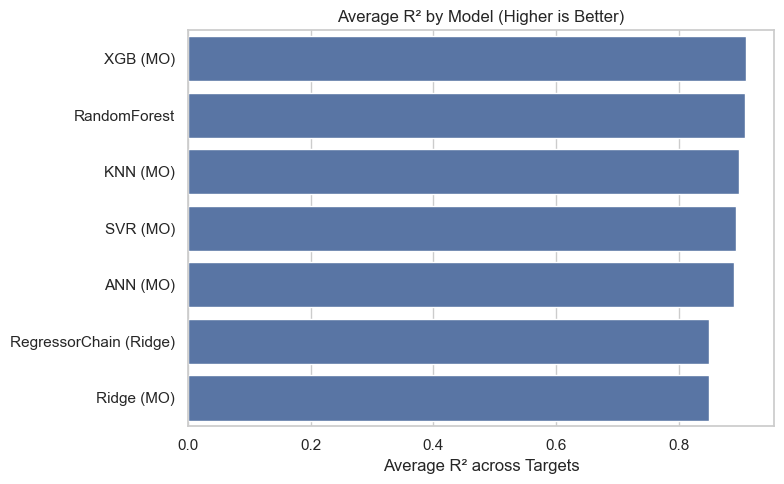

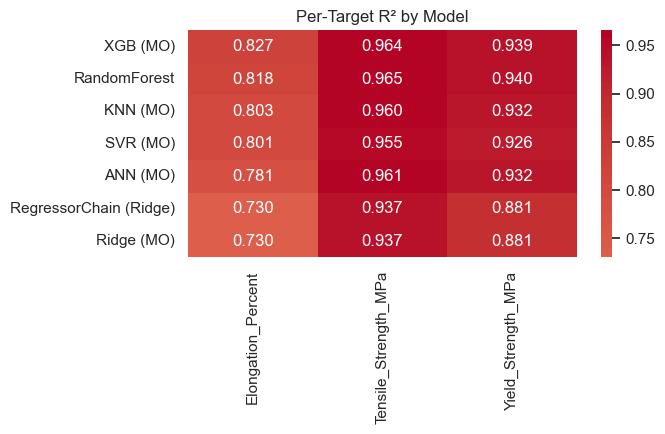

In [41]:
# ===== Compare multi-output models side-by-side =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Collect fitted models that exist in your notebook
candidates = {
    "Ridge (MO)": globals().get("ridge_multi"),
    "RandomForest": globals().get("rf_multi"),
    "XGB (MO)": globals().get("xgb_multi"),
    "SVR (MO)": globals().get("svr_multi"),
    "KNN (MO)": globals().get("knn_multi"),
    "ANN (MO)": globals().get("ann_multi"),
    "RegressorChain (Ridge)": globals().get("chain"),
}

# Evaluate helper
rows = []
for name, mdl in candidates.items():
    if mdl is None:
        continue  # skip models not fitted
    # Predict all 3 targets
    Y_pred = mdl.predict(X_test)  # shape: (n_samples, 3)
    # Compute metrics per target
    for i, t in enumerate(targets):
        y_true = Y_test.iloc[:, i]
        y_hat  = Y_pred[:, i]
        r2   = r2_score(y_true, y_hat)
        rmse = np.sqrt(mean_squared_error(y_true, y_hat))
        mae  = mean_absolute_error(y_true, y_hat)
        rows.append({"Model": name, "Target": t, "R2": r2, "RMSE": rmse, "MAE": mae})

results_df = pd.DataFrame(rows)
if results_df.empty:
    raise RuntimeError("No evaluated models found. Fit at least one of ridge_multi, rf_multi, xgb_multi, svr_multi, knn_multi, ann_multi, or chain before running this cell.")

# Average metrics per model
avg_df = results_df.groupby("Model")[["R2","RMSE","MAE"]].mean().reset_index()
avg_df = avg_df.sort_values("R2", ascending=False)

# ---- Display tables (optional) ----
print("Per-target metrics:")
display(results_df.pivot(index="Model", columns="Target", values="R2").round(3))
print("Average metrics:")
display(avg_df.round(3))

# ---- Plot 1: Average R² by model ----
plt.figure(figsize=(8,5))
sns.barplot(data=avg_df, x="R2", y="Model")
plt.title("Average R² by Model (Higher is Better)")
plt.xlabel("Average R² across Targets")
plt.ylabel("")
plt.tight_layout()
plt.show()

# ---- Plot 2: Per-target R² heatmap ----
heat = results_df.pivot(index="Model", columns="Target", values="R2").loc[avg_df["Model"]]
plt.figure(figsize=(7,4.5))
sns.heatmap(heat, annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("Per-Target R² by Model")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [ ]:
## Hyperparameter Tuning

In [42]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor, RegressorChain

# === Data ===
features = [
    'Furnace_Temp', 'Exist_Temp', 'Annealing_Temp', 'Thickness', 'Width', 'S','Cu','Ni', 
    'Cr', 'Mo', 'V', 'Nb', 'Al', 'Acid Sol. Al', 'Ti', 'B', 'Sn', 'As', 'Zr', 'Ca', 'Pb', 'Ceq', 'Pcm', 'Sb','N','O'
]
targets = ['Tensile_Strength_MPa','Elongation_Percent','Yield_Strength_MPa']

df = combined_data.dropna(subset=features + targets).copy()
X = df[features]
Y = df[targets]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# === Metrics ===
rmse_scorer = make_scorer(lambda yt, yp: -np.sqrt(mean_squared_error(yt, yp)))  # neg for sklearn
def eval_report(y_true, y_pred, label="Model"):
    r2  = [r2_score(y_true.iloc[:,i], y_pred[:,i]) for i in range(Y.shape[1])]
    rm  = [np.sqrt(mean_squared_error(y_true.iloc[:,i], y_pred[:,i])) for i in range(Y.shape[1])]
    ma  = [mean_absolute_error(y_true.iloc[:,i], y_pred[:,i]) for i in range(Y.shape[1])]
    print(f"\n{label}")
    for i, t in enumerate(targets):
        print(f"  {t:>24}: R2={r2[i]:.3f} | RMSE={rm[i]:.3f} | MAE={ma[i]:.3f}")
    print(f"  AVG: R2={np.mean(r2):.3f} | RMSE={np.mean(rm):.3f} | MAE={np.mean(ma):.3f}")


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42, n_jobs=-1)  # multi-output native

rf_dist = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [None, 8, 12, 16, 24],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    rf, rf_dist, n_iter=30, cv=5, scoring=rmse_scorer, random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, Y_train)

rf_best = rf_search.best_estimator_
Y_hat = rf_best.predict(X_test)
eval_report(Y_test, Y_hat, label="RandomForest (tuned)")


Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [ ]:
try:
    from xgboost import XGBRegressor
    xgb_base = XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    )
    xgb = MultiOutputRegressor(xgb_base)

    xgb_dist = {
        "estimator__n_estimators": [300, 500, 800],
        "estimator__learning_rate": [0.03, 0.05, 0.1],
        "estimator__max_depth": [4, 6, 8],
        "estimator__subsample": [0.7, 0.8, 1.0],
        "estimator__colsample_bytree": [0.7, 0.8, 1.0]
    }

    xgb_search = RandomizedSearchCV(
        xgb, xgb_dist, n_iter=25, cv=5, scoring=rmse_scorer, random_state=42, n_jobs=-1, verbose=1
    )
    xgb_search.fit(X_train, Y_train)

    xgb_best = xgb_search.best_estimator_
    Y_hat = xgb_best.predict(X_test)
    eval_report(Y_test, Y_hat, label="XGBoost (tuned)")
except Exception as e:
    print("XGBoost not available or failed to import:", e)


In [ ]:
from sklearn.svm import SVR

svr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR(kernel='rbf'))
])
svr = MultiOutputRegressor(svr_pipe)

svr_dist = {
    "estimator__model__C": [1, 3, 10, 30, 100],
    "estimator__model__gamma": ["scale", 0.1, 0.03, 0.01],
    "estimator__model__epsilon": [0.05, 0.1, 0.2]
}

svr_search = RandomizedSearchCV(
    svr, svr_dist, n_iter=20, cv=5, scoring=rmse_scorer, random_state=42, n_jobs=-1, verbose=1
)
svr_search.fit(X_train, Y_train)

svr_best = svr_search.best_estimator_
Y_hat = svr_best.predict(X_test)
eval_report(Y_test, Y_hat, label="SVR (tuned)")


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor())
])
knn = MultiOutputRegressor(knn_pipe)

knn_dist = {
    "estimator__model__n_neighbors": [5, 8, 10, 15, 25, 35],
    "estimator__model__weights": ["uniform", "distance"],
    "estimator__model__p": [1, 2]  # Manhattan vs Euclidean
}

knn_search = RandomizedSearchCV(
    knn, knn_dist, n_iter=20, cv=5, scoring=rmse_scorer, random_state=42, n_jobs=-1, verbose=1
)
knn_search.fit(X_train, Y_train)

knn_best = knn_search.best_estimator_
Y_hat = knn_best.predict(X_test)
eval_report(Y_test, Y_hat, label="KNN (tuned)")


In [ ]:
from sklearn.neural_network import MLPRegressor

ann_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(max_iter=400, early_stopping=True, random_state=42))
])
ann = MultiOutputRegressor(ann_pipe)

ann_dist = {
    "estimator__model__hidden_layer_sizes": [(256,128), (128,64), (256,128,64)],
    "estimator__model__alpha": [1e-5, 1e-4, 1e-3],
    "estimator__model__learning_rate_init": [1e-3, 3e-3, 1e-2]
}

ann_search = RandomizedSearchCV(
    ann, ann_dist, n_iter=12, cv=5, scoring=rmse_scorer, random_state=42, n_jobs=-1, verbose=1
)
ann_search.fit(X_train, Y_train)

ann_best = ann_search.best_estimator_
Y_hat = ann_best.predict(X_test)
eval_report(Y_test, Y_hat, label="ANN (tuned)")


In [ ]:
from sklearn.linear_model import Ridge

ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(random_state=42))
])
ridge = MultiOutputRegressor(ridge_pipe)

ridge_dist = {
    "estimator__model__alpha": np.logspace(-3, 2, 12)  # 0.001 to 100
}

ridge_search = RandomizedSearchCV(
    ridge, ridge_dist, n_iter=12, cv=5, scoring=rmse_scorer, random_state=42, n_jobs=-1, verbose=1
)
ridge_search.fit(X_train, Y_train)

ridge_best = ridge_search.best_estimator_
Y_hat = ridge_best.predict(X_test)
eval_report(Y_test, Y_hat, label="Ridge (tuned)")


In [ ]:
# Useful if your three targets are interdependent (Yield ↔ Tensile, etc.)
base = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0, random_state=42))])
chain = RegressorChain(base_estimator=base)
chain.fit(X_train, Y_train)
Y_hat = chain.predict(X_test)
eval_report(Y_test, Y_hat, label="RegressorChain(Ridge)")


In [ ]:
!pip install shap



===== XGBoost SHAP: Tensile_Strength_MPa =====


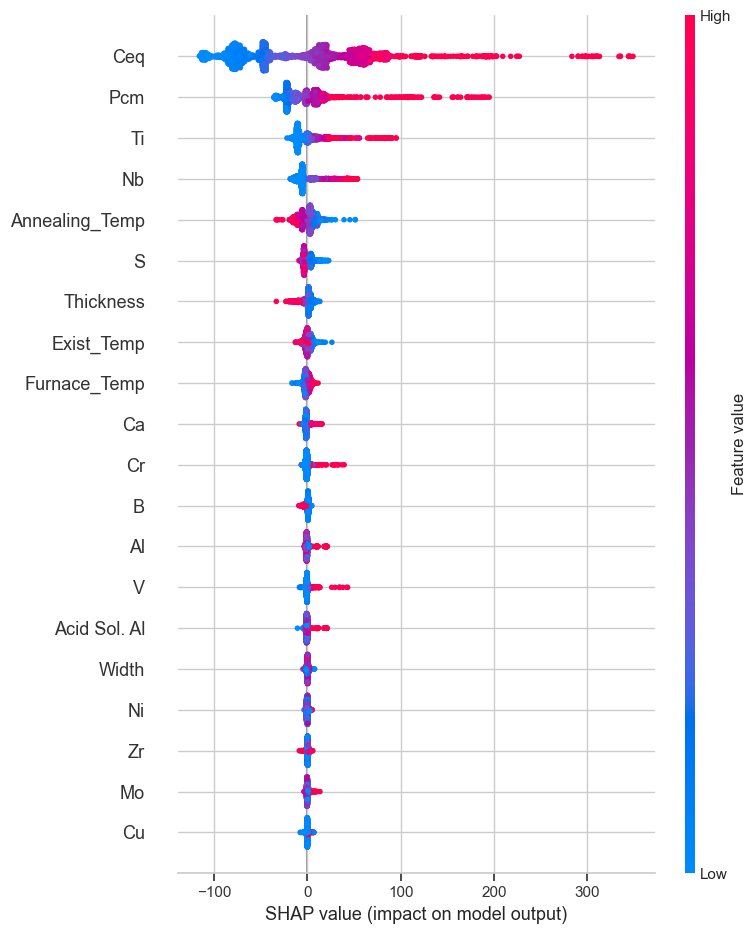

,Feature,Mean(|SHAP|),Std(|SHAP|),Cumulative
21,Ceq,58.461220,41.840145,58.461220
22,Pcm,17.473413,21.539631,75.934631
14,Ti,11.063032,13.014992,86.997665
11,Nb,10.855660,10.047350,97.853325
2,Annealing_Temp,6.621124,4.633023,104.474449
5,S,4.164257,2.295303,108.638702
3,Thickness,3.546392,3.312317,112.185097
1,Exist_Temp,2.660437,2.313511,114.845535
0,Furnace_Temp,2.163054,1.591259,117.008591
19,Ca,1.947236,1.717488,118.955826


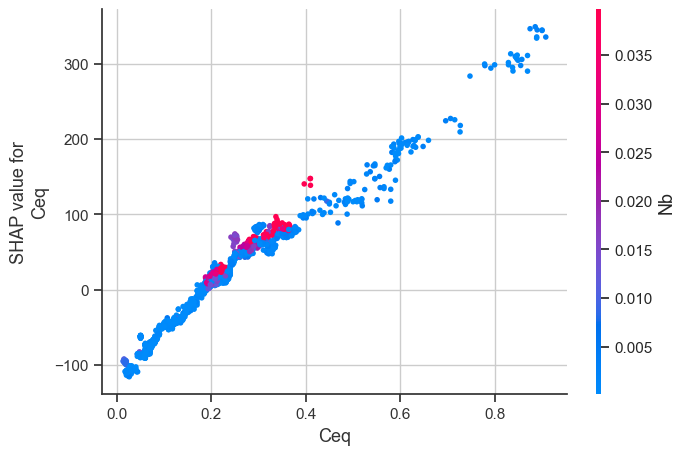

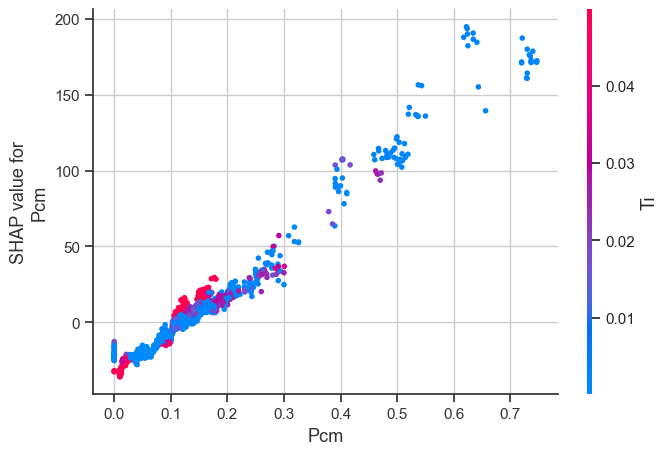


===== XGBoost SHAP: Elongation_Percent =====


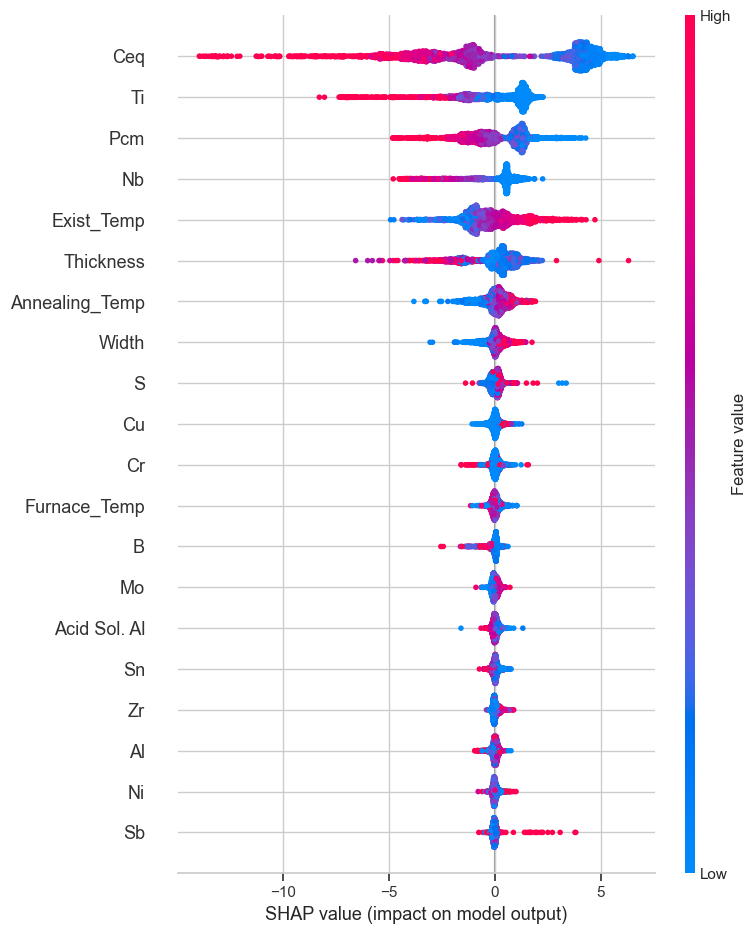

,Feature,Mean(|SHAP|),Std(|SHAP|),Cumulative
21,Ceq,3.533960,1.988475,3.533960
14,Ti,1.362359,1.091983,4.896318
22,Pcm,1.131259,0.768190,6.027578
11,Nb,0.998920,0.896160,7.026498
1,Exist_Temp,0.957363,0.736131,7.983860
3,Thickness,0.792437,0.753161,8.776298
2,Annealing_Temp,0.456974,0.418533,9.233271
4,Width,0.290914,0.299069,9.524184
5,S,0.169852,0.164081,9.694036
6,Cu,0.132709,0.145455,9.826746


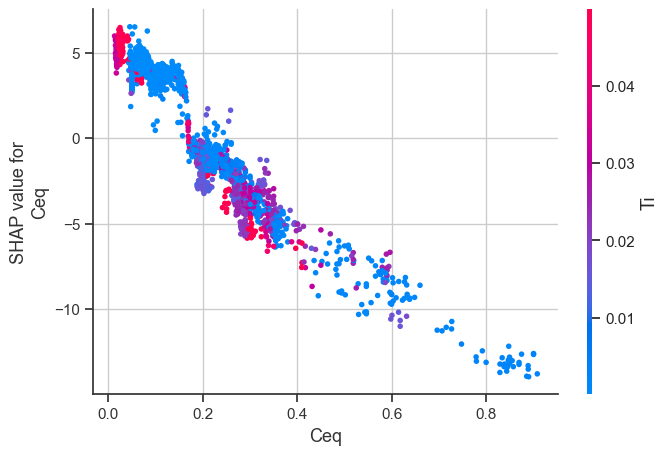

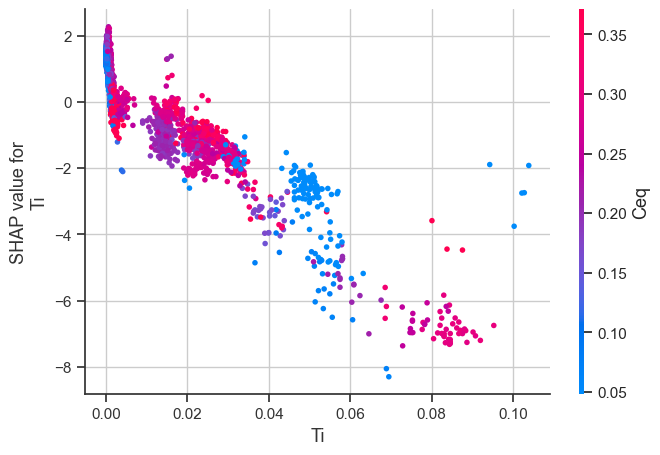


===== XGBoost SHAP: Yield_Strength_MPa =====


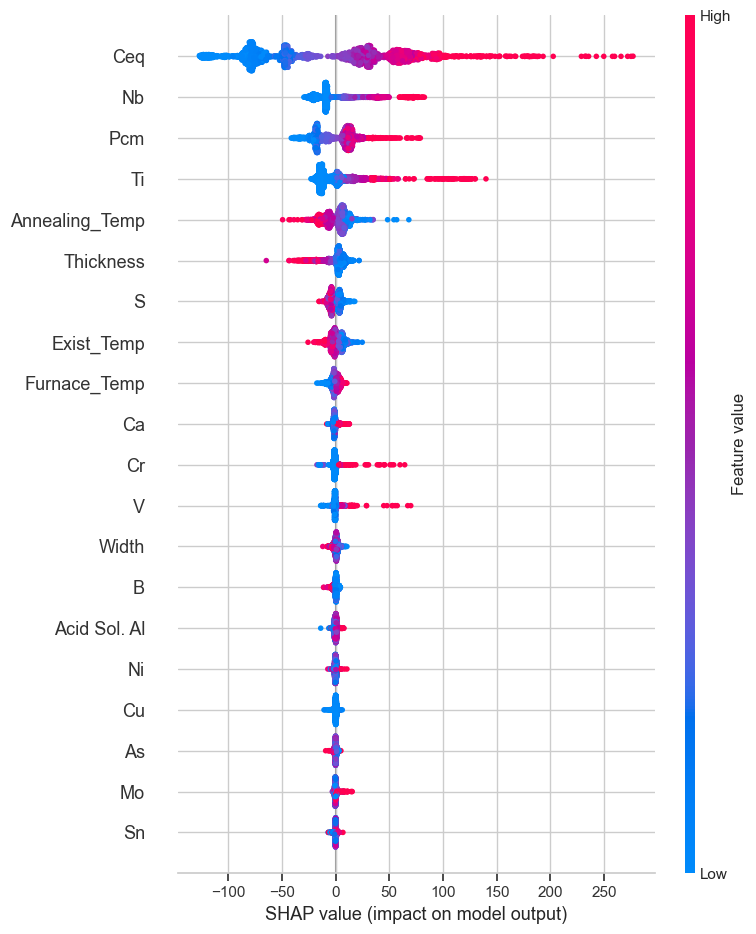

,Feature,Mean(|SHAP|),Std(|SHAP|),Cumulative
21,Ceq,59.381390,33.233730,59.381390
11,Nb,17.976068,15.273772,77.357460
22,Pcm,15.332994,8.439868,92.690453
14,Ti,14.912811,17.753801,107.603264
2,Annealing_Temp,8.450071,5.507416,116.053337
3,Thickness,6.498678,6.453359,122.552017
5,S,4.484971,1.946815,127.036987
1,Exist_Temp,4.286875,3.426257,131.323868
0,Furnace_Temp,2.693302,2.126667,134.017166
19,Ca,1.587583,1.517532,135.604752


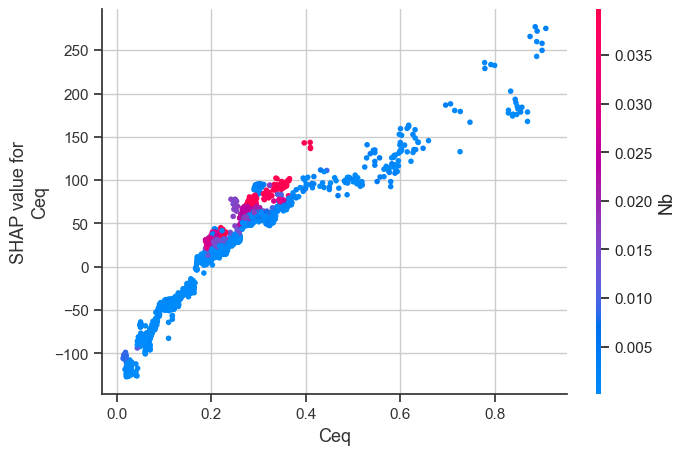

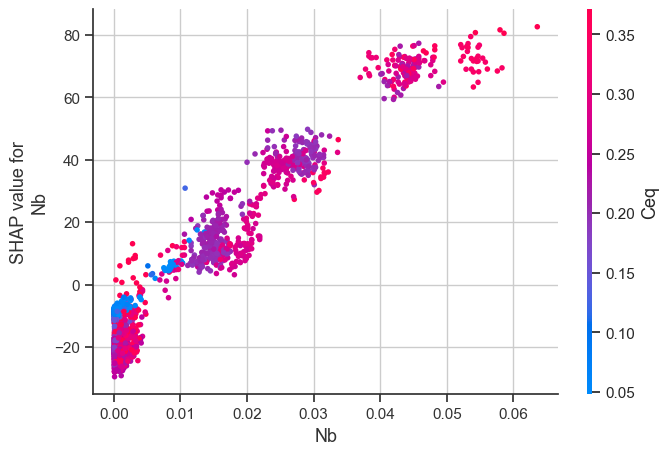

In [42]:
import numpy as np
import pandas as pd
import shap

shap.initjs()

# If you don't already have xgb_best, uncomment:
# xgb_best = xgb_search.best_estimator_

N_SHAP = 3000
X_shap = X_test.sample(n=min(N_SHAP, len(X_test)), random_state=42)

def shap_rank_table(shap_vals, X_df, top_n=15):
    mean_abs = np.abs(shap_vals).mean(axis=0)
    std_abs  = np.abs(shap_vals).std(axis=0)
    out = pd.DataFrame({
        "Feature": X_df.columns,
        "Mean(|SHAP|)": mean_abs,
        "Std(|SHAP|)": std_abs
    }).sort_values("Mean(|SHAP|)", ascending=False)
    out["Cumulative"] = out["Mean(|SHAP|)"].cumsum()
    return out.head(top_n), out

for i, t in enumerate(targets):
    print(f"\n===== XGBoost SHAP: {t} =====")
    est = xgb_best.estimators_[i]              # per-target estimator
    explainer = shap.TreeExplainer(est)
    shap_vals = explainer.shap_values(X_shap)  # (n_samples, n_features)

    shap.summary_plot(shap_vals, X_shap, show=True)

    top15, full = shap_rank_table(shap_vals, X_shap, top_n=15)
    display(top15)

    # Dependence plots for top 2 features (quick + report-friendly)
    for feat in top15["Feature"].tolist()[:2]:
        shap.dependence_plot(feat, shap_vals, X_shap, show=True)
